# Grant analysis in the creative industry 
This research studies the effect of financial grants within the creative industries across 3 cohorts ( software and data , clean tech and non-tech companies). It predicts whether can we , from financial and operational data for pre grant predict the follow on equity investment and survival of companies in the post grant stage. 
## 1.  Exploratory Data Analysis — Unified_Dataset_DG_cleaned


### Load & overview

In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

PATH = '/Users/shalynkee/Downloads/predcitive analytics /dissertiaion /Unified_Dataset_DG_cleaned.xlsx'
df = pd.read_excel(PATH, sheet_name='Sheet1')
print(f'rows={df.shape[0]:,}  cols={df.shape[1]:,}')
df.head()

rows=1,017  cols=157


,CRN_final,Participant Name,Company name,cohort,grant_source,grant_date_real,grant_year,Award Offered (£),post_grant_cohort,post_grant_eligible,Sector,Enterprise Size,enterprise_size_clean,Is Lead Participant,Innovate UK Product Type,Competition Title,prior_iuk_grant_received,total_iuk_grants,grant_rank,Address Region,Public Description,is_sme,borderline_cohort,sub_sector,programme_clean,is_crf,prior_source_grant,source_detail,appears_in_multiple_sources,org_name_clean,award_amount_clean,inc_date,company_age_at_grant,Primary UK SIC (2007) code,R/O Full Postcode,R/O Postal region,Legal form,SME indicator,Number of current directors,no_financial_data,pregrant_year,pregrant_current_assets,pregrant_current_liabilities,pregrant_total_assets,pregrant_long_term_liabilities,pregrant_net_tangible_assets,pregrant_fixed_assets,pregrant_turnover,pregrant_profit_loss,pregrant_creditors,pregrant_total_liabilities,pregrant_net_assets,pregrant_current_ratio,pregrant_leverage_ratio,pregrant_working_capital,pregrant_profit_margin,pregrant_roa,data_observability,cessation_date,growth_stage,employee_count,latest_account_type,Industries,Top-Level Industries,Buzzwords,Sectors,Top-Level Sectors,Target Markets,has_equity_funding,has_mbo_mbi,has_qualifying_loan,attended_accelerator,is_10pct_scaleup,is_20pct_scaleup,academic_spinout,high_growth_list,has_large_innov_grant,SIC Codes (2007) - Code,SIC Codes (2007) - Description,SIC Codes (2007) - Group,sme_status_bh,Director gender balance (% female),Founder gender balance (% female),Key people gender balance (% female),psc1_name,psc1_type,psc1_date,People with Significant Control 1 - Natures of control,psc2_name,psc2_type,psc2_date,People with Significant Control 2 - Natures of control,psc3_name,psc3_type,psc3_date,People with Significant Control 3 - Natures of control,growth_signals,innovation_signals,Environmental signals,Social & Governance signals,Risk signals,Accelerator Attendances - Accelerator Name,Accelerator Attendances - Date the company entered the accelerator,Accelerator Attendances - Date the company left the accelerator,Academic Spinout Events - Academic Institution Name,Academic Spinout Events - Date the company was spun out of the academic institution,High growth list cohorts featuring the company - List name,High growth list cohorts featuring the company - Cohort name,High growth list cohorts featuring the company - Date the list was announced,pre_money_valuation,post_money_valuation,funders,exit_date,acquisition_price,n_grants_bh,total_grants_gbp,Grants - Amount received by the company in its latest grant (GBP),latest_grant_date_bh,earliest_grant_date_bh,n_fundraisings,total_fundraising_gbp,latest_fundraising_gbp,latest_fundraising_date,earliest_fundraising_date,Charges & Mortgages - Total number of charges,Charges & Mortgages - Number of outstanding charges,Charges & Mortgages - Number of fully satisfied charges,dissolution_date,months_to_dissolution,survival_36m,survival_12m,survival_60m,equity_post_grant_flag,equity_reference_date,months_to_first_equity,follow_on_equity_5yr,follow_on_equity_3yr,equity_raised_post_grant,further_grant_bh,further_grant_post_index,corporate_psc_flag,corporate_psc_post_grant,equity_signal,approx_cessation_date,months_to_cessation_dg,survival_12m_dg,survival_36m_dg,survival_60m_dg,director_count_current,sic_code_dg,accounts_overdue,days_since_last_filing,last_accounts_date,accounts_due_date,survival_36m_final,dissolved_flag,company_status_unified
0,02324916,Plymouth College Of Art,PLYMOUTH ARTS CINEMA,Cohort A,BFI,2018-06-20,2018,16880.0,post_grant_eligible,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Education Fund,Education Fund,False,1.0,Historic (2011-2022),1.0,Plymouth College Of Art,16880.0,1988-12-05,29.5,90030.0,PL4 8AT,NaN,Charitable organization,1,8,0,2017,136387,-45689.0,781250,-238103.0,735561,644863.0,588371.0,105436.0,-7511.0,-283792.0,1065042.0,-2.99,-0.363,182076.0,0.179,0.135,High,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN

In [312]:
# Column dtype breakdown
dtypes = df.dtypes.astype(str).value_counts()
print('Dtype counts:')
print(dtypes)
print()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
dt_cols  = df.select_dtypes(include='datetime64[ns]').columns.tolist()
print(f'numeric={len(num_cols)}  categorical={len(cat_cols)}  datetime={len(dt_cols)}')
print(f'\nMemory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')
print(f'Duplicate rows: {df.duplicated().sum()}')
# CRN_final should be a unique firm id
if 'CRN_final' in df.columns:
    print(f'Unique CRN_final: {df["CRN_final"].nunique()} of {len(df)}')

Dtype counts:
object            61
float64           60
int64             18
datetime64[ns]    16
bool               2
Name: count, dtype: int64

numeric=78  categorical=61  datetime=16

Memory: 4.1 MB
Duplicate rows: 0
Unique CRN_final: 618 of 1017


### Missingness

In [313]:
miss = df.isna().mean().sort_values(ascending=False)
miss_pct = (miss * 100).round(1)
print('Columns that are 100% empty:')
print(miss_pct[miss_pct == 100].index.tolist() or 'none')
print(f'\nColumns with >50% missing: {(miss > 0.5).sum()}')
print(f'Columns with 0 missing:    {(miss == 0).sum()}')
print('\nTop 25 most-missing columns:')
miss_pct.head(25)

Columns that are 100% empty:
none

Columns with >50% missing: 103
Columns with 0 missing:    37

Top 25 most-missing columns:


Academic Spinout Events - Date the company was spun out of the academic institution    99.5
Environmental signals                                                                  99.5
Social & Governance signals                                                            99.5
Academic Spinout Events - Academic Institution Name                                    99.5
psc3_name                                                                              99.3
psc3_type                                                                              99.3
psc3_date                                                                              99.3
People with Significant Control 3 - Natures of control                                 99.3
acquisition_price                                                                      99.1
Risk signals                                                                           99.0
exit_date                                                                       

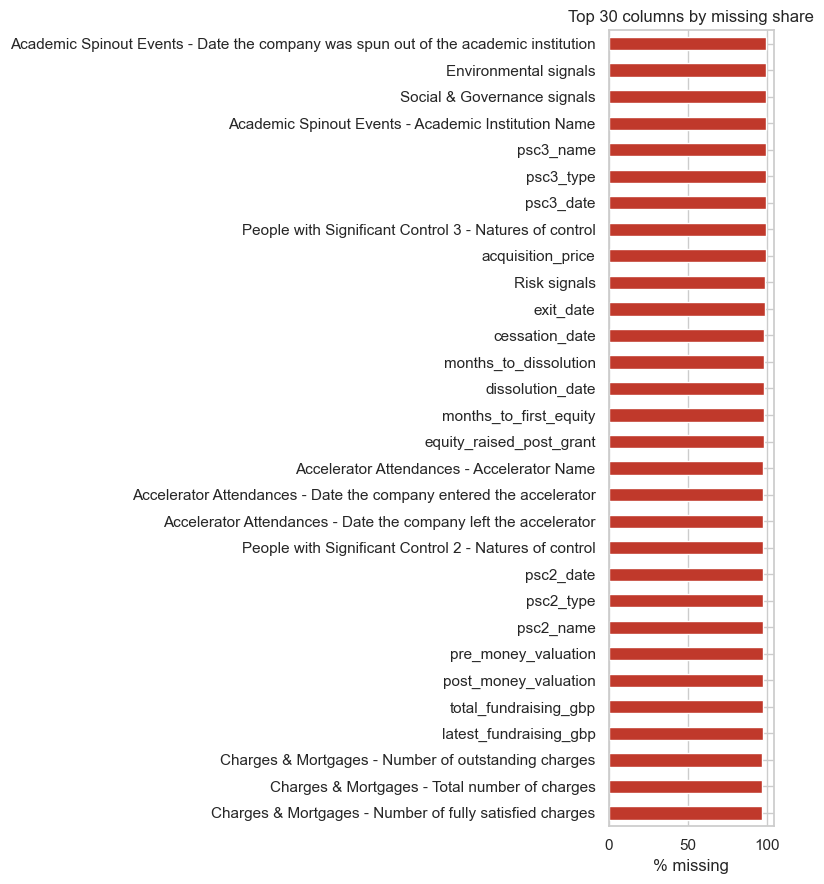

In [314]:
# Visualise missingness for the 30 most-incomplete columns
top_miss = miss_pct[miss_pct > 0].head(30)
fig, ax = plt.subplots(figsize=(8, 9))
top_miss.sort_values().plot.barh(ax=ax, color='#c0392b')
ax.set_xlabel('% missing')
ax.set_title('Top 30 columns by missing share')
plt.tight_layout()
plt.show()

### Numeric profiling

In [315]:
# Drop all-empty numeric columns from the summary for readability
num_nonempty = [c for c in num_cols if df[c].notna().any()]
desc = df[num_nonempty].describe().T
desc['missing_%'] = (df[num_nonempty].isna().mean() * 100).round(1)
desc['n_unique'] = df[num_nonempty].nunique()
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,missing_%,n_unique
grant_year,1017.0,2018.43,1.72,2016.0,2017.0,2018.0,2020.0,2022.0,0.0,7
Award Offered (£),1017.0,92192.31,242246.52,0.0,13916.0,27601.0,79927.0,4143382.0,0.0,768
post_grant_eligible,1017.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0,0.0,1
prior_iuk_grant_received,449.0,0.51,0.50,0.0,0.0,1.0,1.0,1.0,55.9,2
total_iuk_grants,449.0,2.83,3.40,1.0,1.0,2.0,3.0,23.0,55.9,21
...,...,...,...,...,...,...,...,...,...,...
sic_code_dg,1008.0,62971.58,19572.12,1460.0,59111.0,59140.0,74901.0,96090.0,0.9,132
accounts_overdue,1017.0,0.16,0.36,0.0,0.0,0.0,0.0,1.0,0.0,2
days_since_last_filing,1017.0,400.78,560.32,12.0,117.0,220.0,361.0,3398.0,0.0,363
survival_36m_final,1017.0,0.99,0.12,0.0,1.0,1.0,1.0,1.0,0.0,2


In [316]:
# Flag binary/flag columns vs continuous numeric columns
binary_cols = [c for c in num_nonempty if df[c].dropna().isin([0, 1]).all()]
cont_cols   = [c for c in num_nonempty if c not in binary_cols]
print(f'{len(binary_cols)} binary/flag numeric columns:')
print(binary_cols)
print(f'\n{len(cont_cols)} continuous numeric columns')

34 binary/flag numeric columns:
['post_grant_eligible', 'prior_iuk_grant_received', 'grant_rank', 'is_sme', 'borderline_cohort', 'prior_source_grant', 'appears_in_multiple_sources', 'no_financial_data', 'has_mbo_mbi', 'has_qualifying_loan', 'attended_accelerator', 'is_10pct_scaleup', 'is_20pct_scaleup', 'academic_spinout', 'high_growth_list', 'has_large_innov_grant', 'sme_status_bh', 'acquisition_price', 'survival_36m', 'survival_12m', 'survival_60m', 'equity_post_grant_flag', 'follow_on_equity_5yr', 'follow_on_equity_3yr', 'further_grant_bh', 'further_grant_post_index', 'corporate_psc_flag', 'corporate_psc_post_grant', 'survival_12m_dg', 'survival_36m_dg', 'survival_60m_dg', 'accounts_overdue', 'survival_36m_final', 'dissolved_flag']

44 continuous numeric columns


### . Target / outcome variables

The two research outcomes are **post-grant survival** and **follow-on equity investment**. Each exists in **two source families** with very different cohort coverage:

| Family | Columns | Coverage |
|---|---|---|
| **DG-derived** | `survival_12m_dg`, `survival_36m_dg`, `survival_60m_dg`, `dissolved_flag`, `survival_36m_final` | **All 1,017 firms — all 3 cohorts** ✅ |
| **Beauhurst-derived** | `survival_12m/36m/60m`, `follow_on_equity_3yr/5yr`, `equity_post_grant_flag` | Sparse (~100 firms), concentrated in **Cohort B** |

➡️ **Use the DG survival columns** (full cohort A/B/C coverage) as the primary survival target. Follow-on **equity** is only observed via Beauhurst, so that outcome is effectively limited to the Cohort-B subset — a key constraint for the equity-prediction part of the study. The next cell quantifies coverage by cohort.

In [317]:
targets = [c for c in ['survival_12m','survival_36m','survival_60m','survival_36m_final',
                        'survival_12m_dg','survival_36m_dg','survival_60m_dg',
                        'dissolved_flag','follow_on_equity_3yr','follow_on_equity_5yr',
                        'equity_post_grant_flag','further_grant_bh']
           if c in df.columns]
for c in targets:
    vc = df[c].value_counts(dropna=False)
    pos = df[c].mean()
    print(f'{c:24s}  n_obs={df[c].notna().sum():4d}  positive_rate={pos:.3f}  ->  {vc.to_dict()}')

survival_12m              n_obs= 100  positive_rate=1.000  ->  {nan: 917, 1.0: 100}
survival_36m              n_obs= 100  positive_rate=0.990  ->  {nan: 917, 1.0: 99, 0.0: 1}
survival_60m              n_obs= 100  positive_rate=0.920  ->  {nan: 917, 1.0: 92, 0.0: 8}
survival_36m_final        n_obs=1017  positive_rate=0.985  ->  {1: 1002, 0: 15}
survival_12m_dg           n_obs=1017  positive_rate=0.996  ->  {1: 1013, 0: 4}
survival_36m_dg           n_obs=1017  positive_rate=0.985  ->  {1: 1002, 0: 15}
survival_60m_dg           n_obs=1017  positive_rate=0.948  ->  {1: 964, 0: 53}
dissolved_flag            n_obs=1017  positive_rate=0.021  ->  {0: 996, 1: 21}
follow_on_equity_3yr      n_obs= 107  positive_rate=0.084  ->  {nan: 910, 0.0: 98, 1.0: 9}
follow_on_equity_5yr      n_obs= 107  positive_rate=0.112  ->  {nan: 910, 0.0: 95, 1.0: 12}
equity_post_grant_flag    n_obs=  99  positive_rate=0.212  ->  {nan: 918, 0.0: 78, 1.0: 21}
further_grant_bh          n_obs= 107  positive_rate=0.617  -> 

In [318]:
# Outcome coverage (non-null count) by cohort — shows which cohorts each target is observed for
cov_cols = [c for c in ['survival_36m_dg','survival_60m_dg','dissolved_flag',      # DG: full coverage
                        'survival_60m','follow_on_equity_3yr','equity_post_grant_flag']  # Beauhurst: sparse
            if c in df.columns]
coverage = (df.assign(_n=1)
              .groupby('cohort')[cov_cols]
              .apply(lambda g: g.notna().sum())
              .assign(rows=df['cohort'].value_counts()))
print('Observed (non-null) count of each outcome, by cohort:')
print(coverage.T)
print('\n=> DG outcomes cover all three cohorts; Beauhurst survival/equity are Cohort-B-heavy.')

Observed (non-null) count of each outcome, by cohort:
cohort                  Cohort A  Cohort B  Cohort C
survival_36m_dg              568       150       299
survival_60m_dg              568       150       299
dissolved_flag               568       150       299
survival_60m                  15        85         0
follow_on_equity_3yr          17        89         1
equity_post_grant_flag        17        81         1
rows                         568       150       299

=> DG outcomes cover all three cohorts; Beauhurst survival/equity are Cohort-B-heavy.


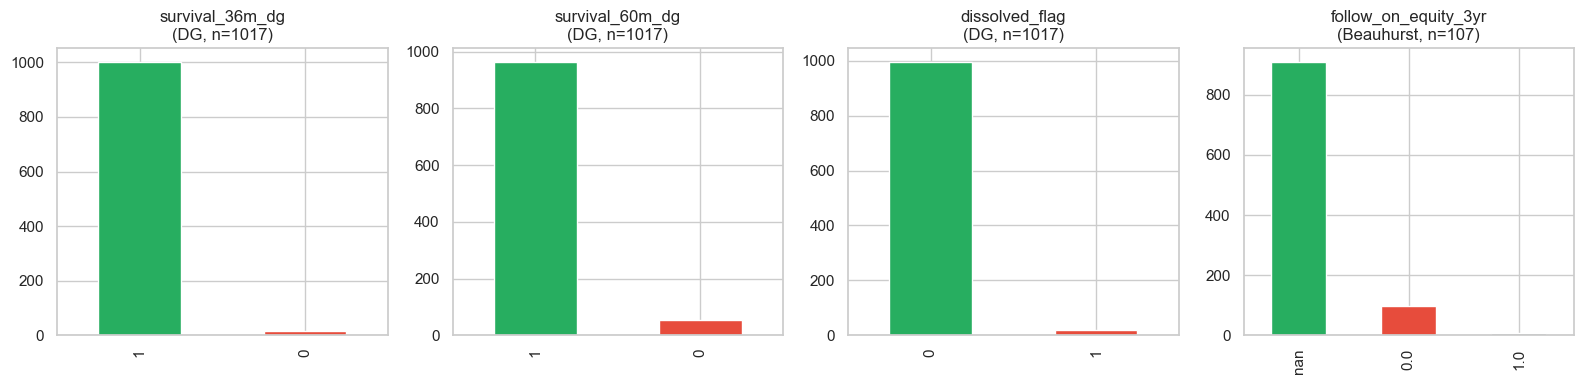

In [319]:
# Class balance for the primary outcomes — DG survival (full cohort coverage) + Beauhurst equity (Cohort-B subset)
plot_targets = [c for c in ['survival_36m_dg','survival_60m_dg','dissolved_flag','follow_on_equity_3yr']
                if c in df.columns]
fig, axes = plt.subplots(1, len(plot_targets), figsize=(4*len(plot_targets), 4))
for ax, c in zip(np.atleast_1d(axes), plot_targets):
    df[c].value_counts(dropna=False).plot.bar(ax=ax, color=['#27ae60','#e74c3c','#95a5a6'])
    src = 'Beauhurst' if c == 'follow_on_equity_3yr' else 'DG'
    ax.set_title(f'{c}\n({src}, n={df[c].notna().sum()})')
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 2. Data cleaning

In [320]:
# --- 10a. Normalise messy values & types (work on a copy) ---
clean = df.copy()

# Replace literal sentinel / blank strings with real NaN across object columns
SENTINELS = {'(no value)', 'n/a', 'N/A', 'na', 'NA', 'none', 'None', '', '-', '--', 'nan'}
obj_cols = clean.select_dtypes(include='object').columns
clean[obj_cols] = clean[obj_cols].apply(lambda s: s.map(lambda x: np.nan if isinstance(x, str) and x.strip() in SENTINELS else x))

# Standardise 'SME indicator' (mixed '1'/'Yes'/'0'/'No'/'Unconfirmed') -> binary 0/1; 'Unconfirmed' -> NaN
if 'SME indicator' in clean.columns:
    sme_map = {'1': 1, 1: 1, 'Yes': 1, 'yes': 1, '0': 0, 0: 0, 'No': 0, 'no': 0, 'Unconfirmed': np.nan}
    clean['SME indicator'] = clean['SME indicator'].map(sme_map)
    print('SME indicator ->', clean['SME indicator'].value_counts(dropna=False).to_dict())

# Coerce pre-grant financial columns to numeric (some imported as text)
pregrant_num = [c for c in clean.columns if c.startswith('pregrant_')]
clean[pregrant_num] = clean[pregrant_num].apply(pd.to_numeric, errors='coerce')
print(f'Coerced {len(pregrant_num)} pregrant_* columns to numeric.')

SME indicator -> {1.0: 999, 0.0: 11, nan: 7}
Coerced 17 pregrant_* columns to numeric.


In [321]:
# --- 10b. Collapse grant-rows -> one row per firm (CRN_final) ---
# Sort so the EARLIEST grant is first; that row is the pre-grant snapshot.
sort_keys = [k for k in ['grant_date_real', 'grant_year'] if k in clean.columns]
clean_sorted = clean.sort_values(sort_keys, na_position='last')

# Targets are firm-level constants -> take max over a firm's rows (defined first so we can
# strip them from the snapshot and avoid duplicate columns on join)
target_cols = [c for c in ['survival_12m_dg','survival_36m_dg','survival_60m_dg','survival_36m_final',
                           'dissolved_flag','survival_12m','survival_36m','survival_60m',
                           'follow_on_equity_3yr','follow_on_equity_5yr','equity_post_grant_flag',
                           'further_grant_bh'] if c in clean.columns]
grp = clean.groupby('CRN_final')
targets_firm = grp[target_cols].max()

# (i) snapshot = earliest grant row per firm, WITHOUT target cols (re-attached cleanly below)
snapshot = (clean_sorted.drop_duplicates('CRN_final', keep='first')
                        .set_index('CRN_final')
                        .drop(columns=target_cols))

# (ii) firm-level aggregates over ALL of a firm's grants
agg = pd.DataFrame({
    'n_grant_rows':          grp.size(),
    'total_award_allgrants': grp['Award Offered (£)'].sum() if 'Award Offered (£)' in clean else grp.size(),
    'first_grant_year':      grp['grant_year'].min() if 'grant_year' in clean else grp.size(),
    'last_grant_year':       grp['grant_year'].max() if 'grant_year' in clean else grp.size(),
})

# (iii) "ever" version of binary flags across a firm's grant history
flag_cols = [c for c in ['attended_accelerator','academic_spinout','high_growth_list',
                         'is_10pct_scaleup','is_20pct_scaleup','has_equity_funding',
                         'has_mbo_mbi','has_qualifying_loan','prior_iuk_grant_received',
                         'has_large_innov_grant'] if c in clean.columns]
ever = grp[flag_cols].max().add_suffix('_ever') if flag_cols else pd.DataFrame(index=snapshot.index)

firm = snapshot.join(agg).join(ever).join(targets_firm).reset_index()
print(f'Collapsed {len(clean):,} grant-rows -> {len(firm):,} firms, {firm.shape[1]} columns')
print('Cohort counts after collapse:'); print(firm['cohort'].value_counts())

Collapsed 1,017 grant-rows -> 618 firms, 171 columns
Cohort counts after collapse:
cohort
Cohort C    299
Cohort A    169
Cohort B    150
Name: count, dtype: int64


In [322]:
# --- 10c. Drop dead weight + quarantine leakage; define predictors vs targets ---

# (0) Force-keep these regardless of the missingness/leakage rules (user request)
#     dissolution_date REMOVED from force_keep — it is post-grant leakage (97.2% missing) -> see leakage list.
force_keep = [c for c in ['accounts_overdue', 'last_accounts_date'] if c in firm.columns]

# (1) Drop columns that are >90% empty at the FIRM level (except force_keep)
firm_miss = firm.isna().mean()
near_empty = [c for c in firm_miss[firm_miss > 0.90].index if c not in force_keep]

# Variables with >80% missingness (firm level) — report before dropping
high_miss_80 = (firm_miss[firm_miss > 0.80] * 100).round(1).sort_values(ascending=False)
print(f'{len(high_miss_80)} variables with >80% missing (firm level, {firm.shape[0]} firms):')
print(high_miss_80.to_string())
print()

# (2) Free-text / identifier columns that aren't model features
id_text = [c for c in ['Participant Name','Company name','org_name_clean','Public Description',
                       'Competition Title','R/O Full Postcode','funders','psc1_name','psc2_name','psc3_name',
                       'source_detail'] if c in firm.columns]

# (3) LEAKAGE: post-grant outcomes / status not known at prediction time, PLUS all-time Beauhurst
#     signal flags (no time anchor to the grant -> may post-date it, esp. for the equity target).
#     NOTE: accounts_overdue, last_accounts_date kept by user request (force_keep).
leakage = [c for c in [
    # firm status / dissolution (post-grant)
    'dissolution_date',  # 97.2% missing, only populated for dissolved firms -> direct survival leakage
    'months_to_dissolution','cessation_date','approx_cessation_date',
    'months_to_cessation_dg','company_status_unified','dissolved_flag','days_since_last_filing',
    'accounts_due_date','latest_account_type','Is Lead Participant', 'Grant Rank','R/O Postal region '
    # exits / valuations / post-grant funding (post-grant)
    'exit_date','acquisition_price','pre_money_valuation','post_money_valuation',
    'equity_raised_post_grant','months_to_first_equity','equity_reference_date','equity_post_grant',
    'equity_signal','n_fundraisings','total_fundraising_gbp','latest_fundraising_gbp',
    'latest_fundraising_date','earliest_fundraising_date','n_grants_bh','total_grants_gbp',
    'latest_grant_date_bh','earliest_grant_date_bh','further_grant_post_index','corporate_psc_post_grant',
    'Grants - Amount received by the company in its latest grant (GBP)',
    # all-time Beauhurst signals (incl. *_ever) — quarantine to be safe; re-include only if time-anchored
    'has_equity_funding','is_10pct_scaleup','is_20pct_scaleup','high_growth_list','attended_accelerator',
    'has_mbo_mbi','has_qualifying_loan','has_large_innov_grant',
    'has_equity_funding_ever','is_10pct_scaleup_ever','is_20pct_scaleup_ever','high_growth_list_ever',
    'attended_accelerator_ever','has_mbo_mbi_ever','has_qualifying_loan_ever','has_large_innov_grant_ever',
    # constants / housekeeping
    'data_observability','post_grant_cohort','post_grant_eligible',
] if c in firm.columns and c not in force_keep]

# (3b) Manually dropped — judged unimportant / redundant for this study
manual_drop = [c for c in [
    'academic_spinout', 'academic_spinout_ever',
    'Buzzwords', 'Top-Level Industries', 'Industries',
    # SIC: keep only sic_code_dg (~99% complete); drop the other four SIC columns
    'Primary UK SIC (2007) code', 'SIC Codes (2007) - Code',
    'SIC Codes (2007) - Description', 'SIC Codes (2007) - Group',
    # employee_count: keep numeric midpoint version (employee_count_num), drop the raw text bands
    'employee_count',
    # SME: keep standardized 'SME indicator'; drop redundant duplicate flags (enterprise_size_clean kept = size band)
    'is_sme', 'sme_status_bh',
    # directors: keep 'Number of current directors' (realistic, <=19); drop director_count_current
    # (DG field, runs to 89 and disagrees 89% of the time -> appears to count all officers/PSCs, not current directors)
    'director_count_current',
    # high-missingness / low-value predictors (70-80% missing, survive the 80% cut)
    'programme_clean',              # 72.7% missing — probably redundant
    'borderline_cohort',            # 75.7% missing — probably drop
    'appears_in_multiple_sources',  # 72.7% missing — interesting but marginal
    # 72.7% missing — only 4/13 dissolved firms have these -> too sparse to be useful features
    'award_amount_clean', 'sub_sector', 'grant_source',
] if c in firm.columns]

# Targets stay out of the predictor matrix
quarantine = set(near_empty) | set(id_text) | set(leakage) | set(manual_drop) | set(target_cols)

# (4) Candidate predictors = everything known at/around grant time that survived the cuts
predictors = [c for c in firm.columns if c not in quarantine and c != 'CRN_final']

print(f'Dropped {len(near_empty)} near-empty (>90%) cols')
print(f'Quarantined {len(leakage)} leakage, {len(id_text)} id/text, {len(manual_drop)} manual-drop, {len(target_cols)} targets')
print('SIC columns kept:', [c for c in predictors if 'sic' in c.lower() or 'SIC' in c])
print('SME / size / employee features kept:', [c for c in predictors if 'SME' in c or 'sme' in c or 'employee' in c or 'enterprise_size' in c])
print('Director columns kept:', [c for c in predictors if 'irector' in c])
print('Kept-by-request in predictors:', [c for c in force_keep if c in predictors])
print(f'\n{len(predictors)} candidate predictor columns:')
print(predictors)

89 variables with >80% missing (firm level, 618 firms):
Academic Spinout Events - Date the company was spun out of the academic institution    99.2
Academic Spinout Events - Academic Institution Name                                    99.2
Social & Governance signals                                                            99.2
Environmental signals                                                                  99.2
psc3_name                                                                              98.9
People with Significant Control 3 - Natures of control                                 98.9
psc3_date                                                                              98.9
psc3_type                                                                              98.9
acquisition_price                                                                      98.5
exit_date                                                                              98.4
Risk signals            

In [323]:
# --- 10d. Assemble clean modelling frame + missingness report ---
import os
model_df = firm[['CRN_final', 'cohort'] + [c for c in predictors if c != 'cohort'] + target_cols].copy()

print(f'model_df: {model_df.shape[0]} firms x {model_df.shape[1]} columns '
      f'({len(predictors)} predictors + {len(target_cols)} targets)\n')

# Missingness of the retained PREDICTORS (what still needs imputation/handling)
pred_miss = (model_df[predictors].isna().mean() * 100).round(1).sort_values(ascending=False)
print('Predictor missingness (top 15):')
print(pred_miss.head(15))

# Save next to the source workbook (derive dir from PATH so the trailing-space folder name is preserved)
out_path = os.path.join(os.path.dirname(PATH), 'firm_level_clean.csv')
model_df.to_csv(out_path, index=False)
print(f'\nSaved -> {out_path}')
model_df.head()

model_df: 618 firms x 64 columns (51 predictors + 12 targets)

Predictor missingness (top 15):
Director gender balance (% female)                        88.8
People with Significant Control 1 - Natures of control    87.5
psc1_date                                                 87.5
psc1_type                                                 87.5
pregrant_roa                                              77.0
pregrant_profit_margin                                    77.0
pregrant_profit_loss                                      77.0
pregrant_turnover                                         76.9
prior_source_grant                                        72.7
pregrant_creditors                                        66.2
pregrant_long_term_liabilities                            57.0
R/O Postal region                                         27.3
prior_iuk_grant_received_ever                             27.3
Enterprise Size                                           27.3
Sector                 

,CRN_final,cohort,grant_date_real,grant_year,Award Offered (£),Sector,Enterprise Size,enterprise_size_clean,Innovate UK Product Type,prior_iuk_grant_received,total_iuk_grants,grant_rank,Address Region,is_crf,prior_source_grant,inc_date,company_age_at_grant,R/O Postal region,Legal form,SME indicator,Number of current directors,no_financial_data,pregrant_year,pregrant_current_assets,pregrant_current_liabilities,pregrant_total_assets,pregrant_long_term_liabilities,pregrant_net_tangible_assets,pregrant_fixed_assets,pregrant_turnover,pregrant_profit_loss,pregrant_creditors,pregrant_total_liabilities,pregrant_net_assets,pregrant_current_ratio,pregrant_leverage_ratio,pregrant_working_capital,pregrant_profit_margin,pregrant_roa,Director gender balance (% female),psc1_type,psc1_date,People with Significant Control 1 - Natures of control,corporate_psc_flag,sic_code_dg,accounts_overdue,last_accounts_date,n_grant_rows,total_award_allgrants,first_grant_year,last_grant_year,prior_iuk_grant_received_ever,survival_12m_dg,survival_36m_dg,survival_60m_dg,survival_36m_final,dissolved_flag,survival_12m,survival_36m,survival_60m,follow_on_equity_3yr,follow_on_equity_5yr,equity_post_grant_flag,further_grant_bh
0,SC414386,Cohort B,2016-01-01,2016,42000.0,AI & Data Economy,Medium,Medium,Procurement,0.0,1.0,1.0,Scotland,False,NaN,2012-12-01,3.1,Scotland,Private Limited,1.0,1,0,2015,223536,-133200.0,280153,-11180.0,146953,56617.0,NaN,NaN,NaN,-144380.0,135773.0,1.67800,0.515361,90336.0,NaN,NaN,0.0,Individual,2016-04-06,Ownership of shares - above 75%,0,74100.0,0,2026-04-10,1,42000.0,2016,2016,0.0,1,1,1,1,0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
1,OC303989,Cohort C,2016-01-01,2016,150854.0,Clean Growth & Infrastructure,Medium,Medium,Collaborative R&D,1.0,2.0,1.0,London,False,NaN,2003-02-25,12.8,London Inner,Limited Liability Partnership,1.0,7,0,2015,5447594,-960616.0,5702739,-2943123.0,4742123,255145.0,12009376.0,2329914.0,17407.0,-3903739.0,1799000.0,5.67100,0.684538,4486978.0,0.194,0.409,NaN,NaN,NaT,NaN,0,NaN,0,2025-09-04,1,150854.0,2016,2016,1.0,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04657089,Cohort C,2016-01-01,2016,20238.0,Clean Growth & Infrastructure,Micro,Micro,Collaborative R&D,0.0,1.0,1.0,South West,False,NaN,2003-05-02,12.7,West Midlands,Private Limited,1.0,0,0,2015,94950,-65933.0,100586,NaN,34653,5636.0,NaN,NaN,NaN,-65933.0,34653.0,1.44000,0.655489,29017.0,NaN,NaN,NaN,NaN,NaT,NaN,0,26513.0,1,2023-11-09,1,20238.0,2016,2016,0.0,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,03509216,Cohort C,2016-01-01,2016,156971.0,Clean Growth & Infrastructure,Medium,Medium,Collaborative R&D,0.0,1.0,1.0,East Midlands,False,NaN,1998-12-02,17.1,North West,Private Limited,1.0,2,0,2015,3769419,-1589011.0,5818731,-341759.0,4229720,2049312.0,6620432.0,621331.0,314.0,-1930770.0,3887961.0,2.37200,0.331820,2180408.0,0.094,0.107,NaN,NaN,NaT,NaN,0,25110.0,1,2024-12-24,1,156971.0,2016,2016,0.0,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,09221340,Cohort C,2016-01-01,2016,290977.0,Clean Growth & Infrastructure,Micro,Micro,Collaborative R&D,1.0,9.0,1.0,East of England,False,NaN,2014-09-16,1.3,Eastern,Private Limited,1.0,2,0,2015,1254861,-13072.0,1294861,NaN,1241789,40000.0,NaN,NaN,NaN,-13072.0,1281789.0,89.16025,0.011593,1241789.0,NaN,NaN,NaN,NaN,NaT,NaN,0,72190.0,0,2025-07-12,1,290977.0,2016,2016,1.0,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [324]:
# --- Remove predictors with > 80% missingness ---
# Recompute predictor missingness on the firm-level frame and drop anything above the threshold.

pred_miss_frac = model_df[predictors].isna().mean()
drop_high_miss = pred_miss_frac[(pred_miss_frac > MISS_THRESH)
                                & (~pred_miss_frac.index.isin(force_keep))].sort_values(ascending=False)

print(f'Dropping {len(drop_high_miss)} predictors with >{MISS_THRESH:.0%} missing:')
print((drop_high_miss * 100).round(1).to_string() or 'none')
protected = [c for c in force_keep if c in predictors and pred_miss_frac.get(c, 0) > MISS_THRESH]
print(f'Protected (force_keep, kept despite >{MISS_THRESH:.0%} missing): {protected or "none"}')

# Update predictor list + modelling frame
predictors = [c for c in predictors if c not in drop_high_miss.index]
model_df = model_df.drop(columns=list(drop_high_miss.index))

print(f'\nRemaining predictors: {len(predictors)}')
print(f'model_df now: {model_df.shape[0]} firms x {model_df.shape[1]} columns '
      f'({len(predictors)} predictors + {len(target_cols)} targets)')

# Re-save the cleaned frame
model_df.to_csv(out_path, index=False)
print(f'Re-saved -> {out_path}')

Dropping 4 predictors with >80% missing:
Director gender balance (% female)                        88.8
psc1_type                                                 87.5
psc1_date                                                 87.5
People with Significant Control 1 - Natures of control    87.5
Protected (force_keep, kept despite >80% missing): none

Remaining predictors: 47
model_df now: 618 firms x 60 columns (47 predictors + 12 targets)
Re-saved -> /Users/shalynkee/Downloads/predcitive analytics /dissertiaion /firm_level_clean.csv


## 3. EDA on the produced firm-level dataset (`firm_level_clean.csv`)

The cells above profiled the *raw* grant-row data. This section runs EDA on the **dataset produced by the cleaning pipeline** — the leakage-safe, firm-level modelling frame (`model_df`, one row per `CRN_final`, saved to `firm_level_clean.csv`). Focus: outcome prevalence, pre-grant feature distributions, and how predictors relate to the survival / follow-on-equity targets.

In [325]:
# --- EDA-1. Load the produced firm-level dataset (firm_level_clean.csv) ---
EDA_PATH = out_path if 'out_path' in dir() else os.path.join(os.path.dirname(PATH), 'firm_level_cleannn.csv')
eda = pd.read_csv(EDA_PATH)

print(f'rows={eda.shape[0]:,}  cols={eda.shape[1]:,}   source={EDA_PATH}')
print(f'Unique CRN_final: {eda["CRN_final"].nunique()}  (expect = rows -> one row per firm)')
print(f'Duplicate rows: {eda.duplicated().sum()}')
print('\nCohort counts:'); print(eda['cohort'].value_counts())
print('\nDtype counts:'); print(eda.dtypes.astype(str).value_counts())
print(f'\nMean missingness across all cells: {eda.isna().mean().mean()*100:.1f}%')
print(f'Columns >50% missing: {(eda.isna().mean() > 0.5).sum()}   |   0 missing: {(eda.isna().mean()==0).sum()}')
eda.head()

rows=618  cols=60   source=/Users/shalynkee/Downloads/predcitive analytics /dissertiaion /firm_level_clean.csv
Unique CRN_final: 618  (expect = rows -> one row per firm)
Duplicate rows: 0

Cohort counts:
cohort
Cohort C    299
Cohort A    169
Cohort B    150
Name: count, dtype: int64

Dtype counts:
float64    30
int64      17
object     12
bool        1
Name: count, dtype: int64

Mean missingness across all cells: 23.7%
Columns >50% missing: 14   |   0 missing: 27


,CRN_final,cohort,grant_date_real,grant_year,Award Offered (£),Sector,Enterprise Size,enterprise_size_clean,Innovate UK Product Type,prior_iuk_grant_received,total_iuk_grants,grant_rank,Address Region,is_crf,prior_source_grant,inc_date,company_age_at_grant,R/O Postal region,Legal form,SME indicator,Number of current directors,no_financial_data,pregrant_year,pregrant_current_assets,pregrant_current_liabilities,pregrant_total_assets,pregrant_long_term_liabilities,pregrant_net_tangible_assets,pregrant_fixed_assets,pregrant_turnover,pregrant_profit_loss,pregrant_creditors,pregrant_total_liabilities,pregrant_net_assets,pregrant_current_ratio,pregrant_leverage_ratio,pregrant_working_capital,pregrant_profit_margin,pregrant_roa,corporate_psc_flag,sic_code_dg,accounts_overdue,last_accounts_date,n_grant_rows,total_award_allgrants,first_grant_year,last_grant_year,prior_iuk_grant_received_ever,survival_12m_dg,survival_36m_dg,survival_60m_dg,survival_36m_final,dissolved_flag,survival_12m,survival_36m,survival_60m,follow_on_equity_3yr,follow_on_equity_5yr,equity_post_grant_flag,further_grant_bh
0,SC414386,Cohort B,2016-01-01,2016,42000.0,AI & Data Economy,Medium,Medium,Procurement,0.0,1.0,1.0,Scotland,False,NaN,2012-12-01,3.1,Scotland,Private Limited,1.0,1,0,2015,223536,-133200.0,280153,-11180.0,146953,56617.0,NaN,NaN,NaN,-144380.0,135773.0,1.67800,0.515361,90336.0,NaN,NaN,0,74100.0,0,2026-04-10,1,42000.0,2016,2016,0.0,1,1,1,1,0,1.0,1.0,1.0,0.0,0.0,0.0,1.0
1,OC303989,Cohort C,2016-01-01,2016,150854.0,Clean Growth & Infrastructure,Medium,Medium,Collaborative R&D,1.0,2.0,1.0,London,False,NaN,2003-02-25,12.8,London Inner,Limited Liability Partnership,1.0,7,0,2015,5447594,-960616.0,5702739,-2943123.0,4742123,255145.0,12009376.0,2329914.0,17407.0,-3903739.0,1799000.0,5.67100,0.684538,4486978.0,0.194,0.409,0,NaN,0,2025-09-04,1,150854.0,2016,2016,1.0,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04657089,Cohort C,2016-01-01,2016,20238.0,Clean Growth & Infrastructure,Micro,Micro,Collaborative R&D,0.0,1.0,1.0,South West,False,NaN,2003-05-02,12.7,West Midlands,Private Limited,1.0,0,0,2015,94950,-65933.0,100586,NaN,34653,5636.0,NaN,NaN,NaN,-65933.0,34653.0,1.44000,0.655489,29017.0,NaN,NaN,0,26513.0,1,2023-11-09,1,20238.0,2016,2016,0.0,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,03509216,Cohort C,2016-01-01,2016,156971.0,Clean Growth & Infrastructure,Medium,Medium,Collaborative R&D,0.0,1.0,1.0,East Midlands,False,NaN,1998-12-02,17.1,North West,Private Limited,1.0,2,0,2015,3769419,-1589011.0,5818731,-341759.0,4229720,2049312.0,6620432.0,621331.0,314.0,-1930770.0,3887961.0,2.37200,0.331820,2180408.0,0.094,0.107,0,25110.0,1,2024-12-24,1,156971.0,2016,2016,0.0,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,09221340,Cohort C,2016-01-01,2016,290977.0,Clean Growth & Infrastructure,Micro,Micro,Collaborative R&D,1.0,9.0,1.0,East of England,False,NaN,2014-09-16,1.3,Eastern,Private Limited,1.0,2,0,2015,1254861,-13072.0,1294861,NaN,1241789,40000.0,NaN,NaN,NaN,-13072.0,1281789.0,89.16025,0.011593,1241789.0,NaN,NaN,0,72190.0,0,2025-07-12,1,290977.0,2016,2016,1.0,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Outcome prevalence (firm level)

DG survival / dissolution (all 618 firms):
  survival_12m_dg      pos_rate=0.997  n=618
  survival_36m_dg      pos_rate=0.979  n=618
  survival_60m_dg      pos_rate=0.924  n=618
  dissolved_flag       pos_rate=0.034  n=618

Beauhurst equity (sparse, Cohort-B-heavy):
  follow_on_equity_3yr     pos_rate=0.099  n=91
  follow_on_equity_5yr     pos_rate=0.132  n=91
  equity_post_grant_flag   pos_rate=0.253  n=83

5-yr survival (survival_60m_dg) by cohort:
           mean  count
cohort                
Cohort A  0.947    169
Cohort B  0.887    150
Cohort C  0.930    299


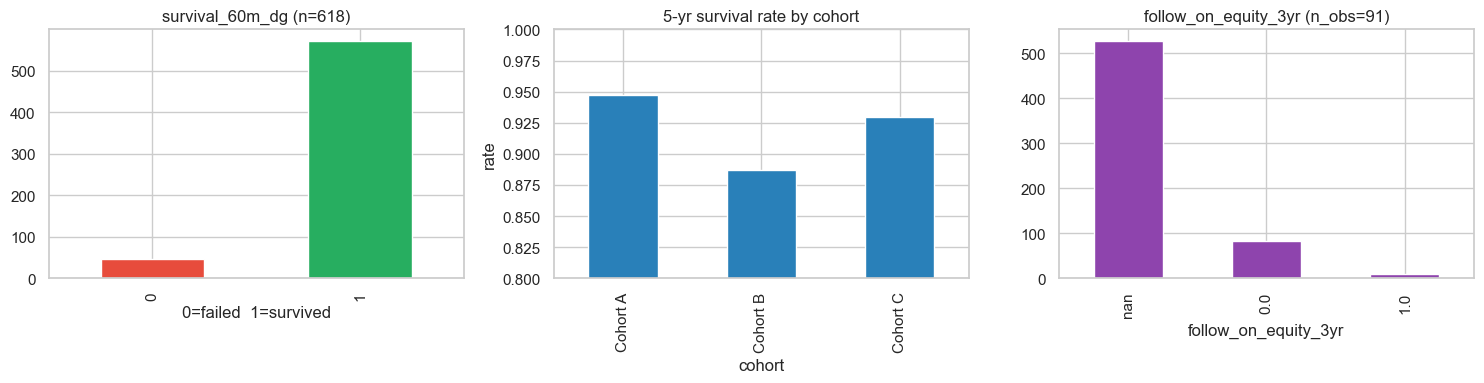

In [326]:
# --- EDA-2. Outcome prevalence at firm level ---
surv_targets = ['survival_12m_dg','survival_36m_dg','survival_60m_dg','dissolved_flag']
eq_targets   = ['follow_on_equity_3yr','follow_on_equity_5yr','equity_post_grant_flag']
print('DG survival / dissolution (all 618 firms):')
for c in surv_targets:
    print(f'  {c:20s} pos_rate={eda[c].mean():.3f}  n={eda[c].notna().sum()}')
print('\nBeauhurst equity (sparse, Cohort-B-heavy):')
for c in eq_targets:
    print(f'  {c:24s} pos_rate={eda[c].mean():.3f}  n={eda[c].notna().sum()}')

by_cohort = eda.groupby('cohort')['survival_60m_dg'].agg(['mean','count']).round(3)
print('\n5-yr survival (survival_60m_dg) by cohort:'); print(by_cohort)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
eda['survival_60m_dg'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#e74c3c','#27ae60'])
axes[0].set_title('survival_60m_dg (n=618)'); axes[0].set_xlabel('0=failed  1=survived')
by_cohort['mean'].plot.bar(ax=axes[1], color='#2980b9'); axes[1].set_ylim(0.8, 1.0)
axes[1].set_title('5-yr survival rate by cohort'); axes[1].set_ylabel('rate')
eda['follow_on_equity_3yr'].value_counts(dropna=False).plot.bar(ax=axes[2], color='#8e44ad')
axes[2].set_title(f'follow_on_equity_3yr (n_obs={eda["follow_on_equity_3yr"].notna().sum()})')
plt.tight_layout(); plt.show()

### Pre-grant financial & operational features

Numeric feature profile (sorted by skew):
                                count        mean        50%          std           min           max  missing_%  skew
pregrant_total_assets           618.0  10145460.1   166904.0  138159848.2  1.000000e+00  3.317000e+09        0.0  22.5
pregrant_fixed_assets           496.0   7473902.7    13375.0  113719319.1  1.000000e+00  2.468000e+09       19.7  20.8
pregrant_net_assets             596.0   5233587.6    89078.0   59547532.6 -1.902197e+07  1.327000e+09        3.6  19.4
n_grant_rows                    618.0         1.6        1.0          4.2  1.000000e+00  9.200000e+01        0.0  17.3
pregrant_current_assets         618.0   4146988.0   135300.0   42240831.9  1.000000e+00  8.490000e+08        0.0  16.6
pregrant_net_tangible_assets    618.0   2555471.1    50683.5   20339844.3 -1.895003e+07  3.955030e+08        0.0  14.7
pregrant_creditors              209.0    110530.1     5989.0    1978241.8 -9.000000e+06  2.669600e+07       66.2  11.3
pregra

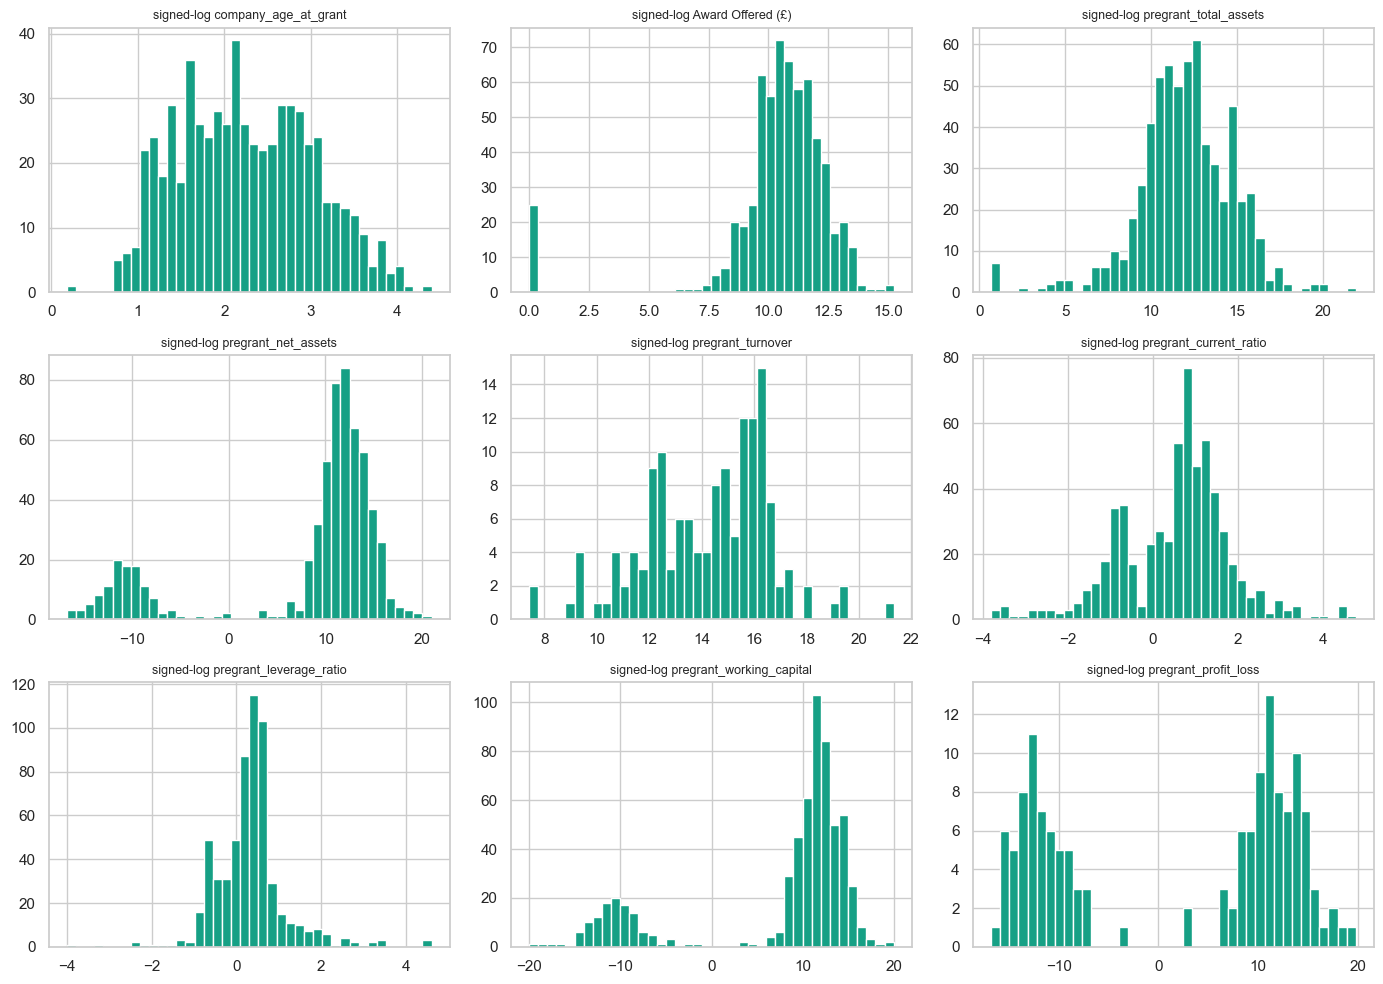

In [327]:
# --- EDA-3. Pre-grant financial & operational features: distributions ---
pregrant = [c for c in eda.columns if c.startswith('pregrant_')]
core_num = ['company_age_at_grant','Award Offered (£)','total_award_allgrants',
            'Number of current directors','total_iuk_grants','n_grant_rows']
num_feats = [c for c in core_num + pregrant if c in eda.columns]

prof = eda[num_feats].describe().T
prof['missing_%'] = (eda[num_feats].isna().mean() * 100).round(1)
prof['skew'] = eda[num_feats].skew().round(2)
print('Numeric feature profile (sorted by skew):')
print(prof[['count','mean','50%','std','min','max','missing_%','skew']]
      .sort_values('skew', ascending=False).round(1).to_string())

# signed-log histograms (financials are heavily skewed and include negatives)
slog = lambda s: np.sign(s) * np.log1p(s.abs())
show = ['company_age_at_grant','Award Offered (£)','pregrant_total_assets',
        'pregrant_net_assets','pregrant_turnover','pregrant_current_ratio',
        'pregrant_leverage_ratio','pregrant_working_capital','pregrant_profit_loss']
show = [c for c in show if c in eda.columns]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, c in zip(axes.ravel(), show):
    slog(eda[c].dropna()).hist(bins=40, ax=ax, color='#16a085')
    ax.set_title(f'signed-log {c}', fontsize=9)
plt.tight_layout(); plt.show()

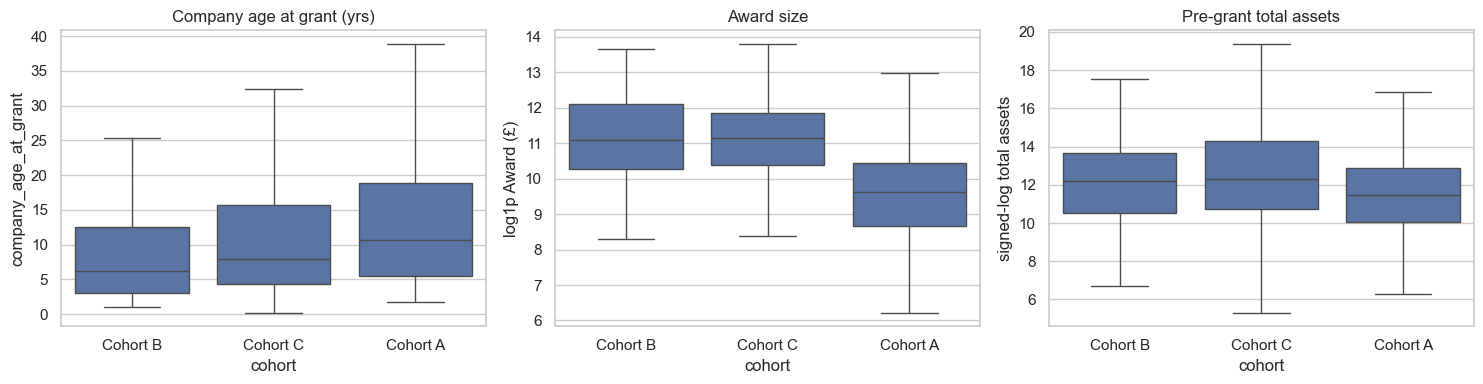

In [328]:
# --- EDA-4. Firm scale & age across cohorts ---
signed_log = lambda s: np.sign(s) * np.log1p(s.abs())
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=eda, x='cohort', y='company_age_at_grant', ax=axes[0], showfliers=False)
axes[0].set_title('Company age at grant (yrs)')

tmp = eda.assign(_logaward=np.log1p(eda['Award Offered (£)']),
                 _logta=signed_log(eda['pregrant_total_assets']))
sns.boxplot(data=tmp, x='cohort', y='_logaward', ax=axes[1], showfliers=False)
axes[1].set_title('Award size'); axes[1].set_ylabel('log1p Award (£)')
sns.boxplot(data=tmp, x='cohort', y='_logta', ax=axes[2], showfliers=False)
axes[2].set_title('Pre-grant total assets'); axes[2].set_ylabel('signed-log total assets')
plt.tight_layout(); plt.show()

### Categorical structure & survival rates


Sector  (27% missing):
Sector
Clean Growth & Infrastructure    299
NaN                              169
AI & Data Economy                150

enterprise_size_clean  (27% missing):
enterprise_size_clean
Micro          201
NaN            169
Micro/Small    100
Small           92
Medium          56

Legal form  (0% missing):
Legal form
Private Limited                  514
Charitable organization           51
Guarantee                         42
Limited Liability Partnership      9
Public, Quoted                     2

R/O Postal region  (27% missing):
R/O Postal region
NaN              169
London Inner      86
Southern          72
South Western     41
Scotland          39
North West        34
Eastern           34
West Midlands     28

Innovate UK Product Type  (27% missing):
Innovate UK Product Type
Collaborative R&D                     224
Feasibility Studies                   191
NaN                                   169
Small Business Research Initiative     19
Procurement            

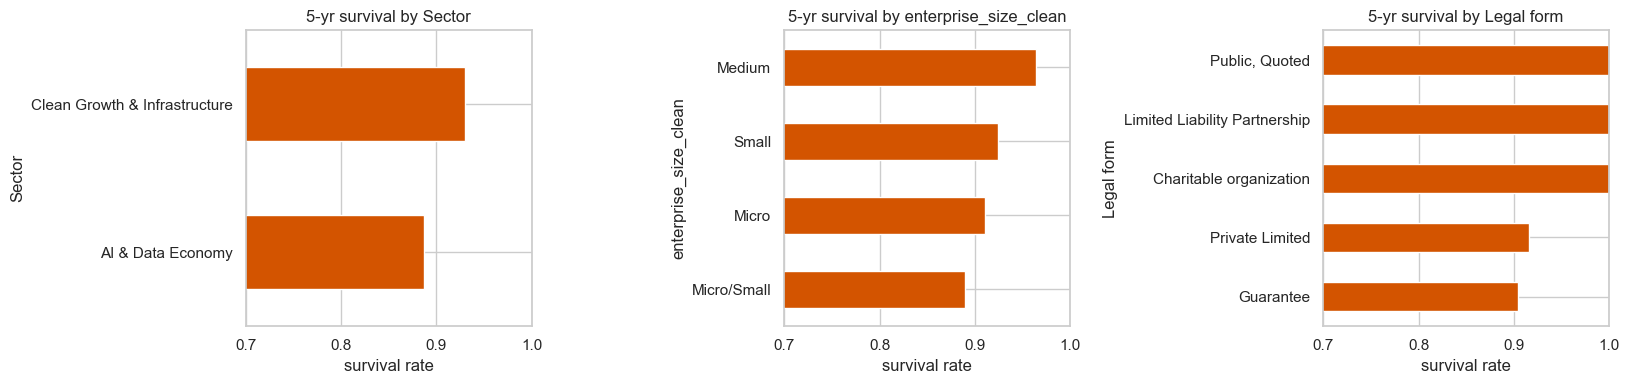

In [329]:
# --- EDA-5. Categorical structure & survival rates ---
cat_feats = ['Sector','enterprise_size_clean','Legal form','R/O Postal region',
             'Innovate UK Product Type','Address Region']
for c in cat_feats:
    if c in eda.columns:
        print(f'\n{c}  ({eda[c].isna().mean()*100:.0f}% missing):')
        print(eda[c].value_counts(dropna=False).head(8).to_string())

# 5-yr survival rate by selected categoricals
plot_cats = [c for c in ['Sector','enterprise_size_clean','Legal form'] if c in eda.columns]
fig, axes = plt.subplots(1, len(plot_cats), figsize=(5.5*len(plot_cats), 4))
for ax, c in zip(np.atleast_1d(axes), plot_cats):
    g = eda.groupby(c)['survival_60m_dg'].mean().sort_values()
    g.plot.barh(ax=ax, color='#d35400'); ax.set_xlim(0.7, 1.0)
    ax.set_title(f'5-yr survival by {c}'); ax.set_xlabel('survival rate')
plt.tight_layout(); plt.show()

### Correlations & feature–outcome relationships

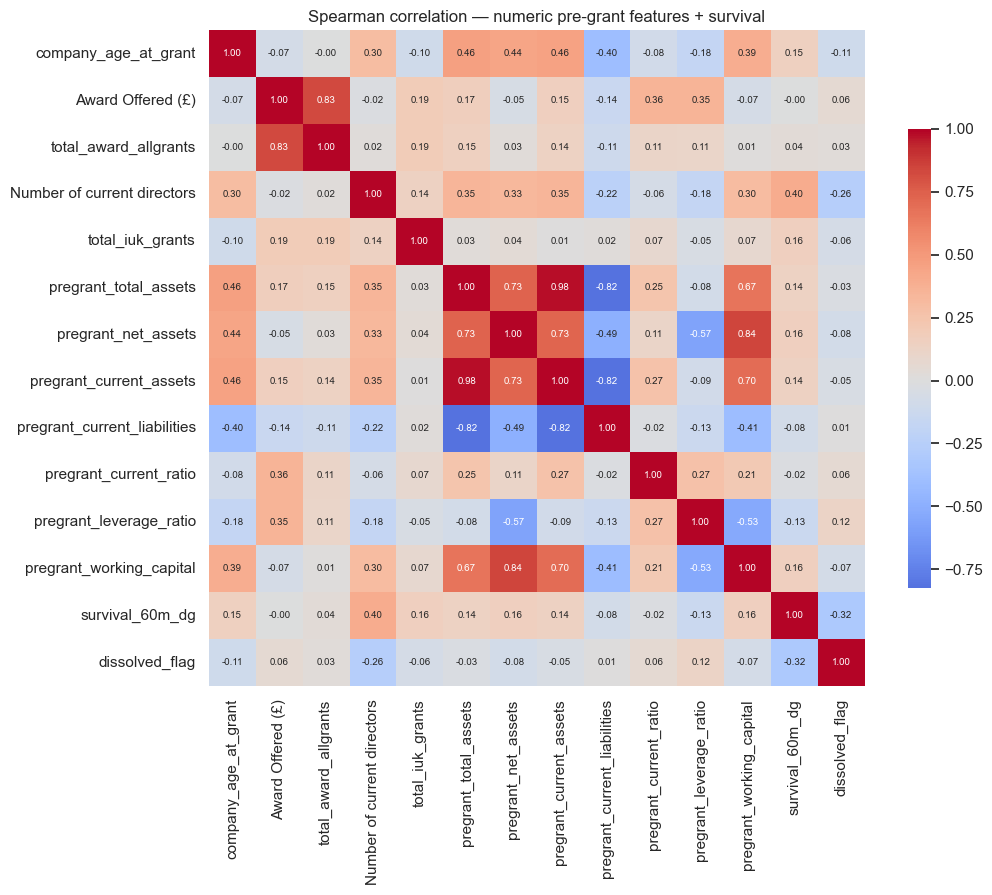

In [330]:
# --- EDA-6. Correlation among numeric pre-grant features + survival ---
corr_cols = ['company_age_at_grant','Award Offered (£)','total_award_allgrants',
             'Number of current directors','total_iuk_grants',
             'pregrant_total_assets','pregrant_net_assets','pregrant_current_assets',
             'pregrant_current_liabilities','pregrant_current_ratio','pregrant_leverage_ratio',
             'pregrant_working_capital','survival_60m_dg','dissolved_flag']
corr_cols = [c for c in corr_cols if c in eda.columns]
corr = eda[corr_cols].corr(method='spearman')   # Spearman: robust to the heavy skew

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'shrink': .7}, annot_kws={'size': 7}, ax=ax)
ax.set_title('Spearman correlation — numeric pre-grant features + survival')
plt.tight_layout(); plt.show()

Median pre-grant feature by survival_60m_dg (0=dissolved/failed, 1=survived):
survival_60m_dg                     0          1
company_age_at_grant             4.20       8.50
Award Offered (£)            42000.00   46405.00
pregrant_total_assets        37391.00  181903.00
pregrant_net_assets           9713.00  103955.00
pregrant_current_ratio           1.13       1.11
pregrant_leverage_ratio          0.77       0.38
Number of current directors      0.00       2.00


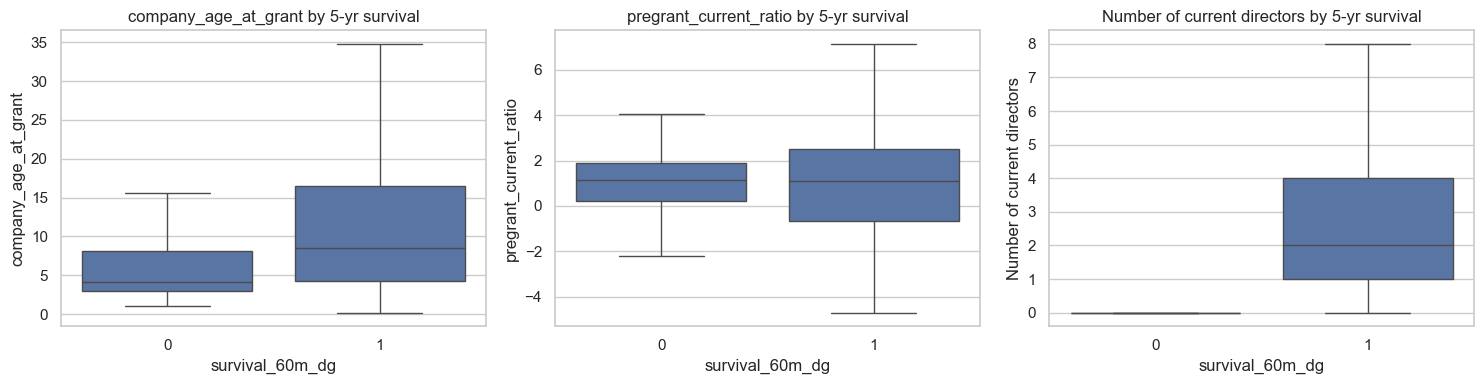


Equity subset: n=91  pos_rate=0.099  cohorts={'Cohort B': 89, 'Cohort C': 1, 'Cohort A': 1}
Median pre-grant feature by follow_on_equity_3yr:
follow_on_equity_3yr               0.0        1.0
company_age_at_grant              6.30       2.20
Award Offered (£)             42000.00  139827.00
pregrant_total_assets        178172.50   79618.00
pregrant_net_assets           39135.50   15593.00
pregrant_current_ratio            1.54       3.16
pregrant_leverage_ratio           0.66       0.26
Number of current directors       2.00       0.00


In [331]:
# --- EDA-7. Pre-grant features vs outcomes (bivariate) ---
feat = ['company_age_at_grant','Award Offered (£)','pregrant_total_assets',
        'pregrant_net_assets','pregrant_current_ratio','pregrant_leverage_ratio',
        'Number of current directors']
feat = [c for c in feat if c in eda.columns]

# (a) Survival: median feature value by 5-yr survival outcome
print('Median pre-grant feature by survival_60m_dg (0=dissolved/failed, 1=survived):')
print(eda.groupby('survival_60m_dg')[feat].median().round(2).T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, ['company_age_at_grant','pregrant_current_ratio','Number of current directors']):
    sns.boxplot(data=eda, x='survival_60m_dg', y=c, ax=ax, showfliers=False)
    ax.set_title(f'{c} by 5-yr survival')
plt.tight_layout(); plt.show()

# (b) Follow-on equity (only where observed -> effectively Cohort B)
eq = eda[eda['follow_on_equity_3yr'].notna()]
print(f'\nEquity subset: n={len(eq)}  pos_rate={eq["follow_on_equity_3yr"].mean():.3f}  '
      f'cohorts={eq["cohort"].value_counts().to_dict()}')
print('Median pre-grant feature by follow_on_equity_3yr:')
print(eq.groupby('follow_on_equity_3yr')[feat].median().round(2).T)

### EDA summary — key takeaways for modelling

**Dataset:** `firm_level_clean.csv` — 618 firms (one row per `CRN_final`), 61 columns. Cohorts: C=299, A=169, B=150.

1. **Severe target imbalance (survival).** 5-yr DG survival = **92.4%** positive; `dissolved_flag` only **3.4%**. 12m/36m survival are even more skewed (≈99.7% / 97.9%). → Use **PR-AUC / recall on the minority (dissolved) class**, class weights or resampling; plain accuracy is meaningless here.
2. **Equity outcome is structurally limited.** `follow_on_equity_3yr` is observed for only **91 firms — essentially all Cohort B** (Beauhurst coverage), positive rate ≈10%. Equity prediction is realistically a **Cohort-B-only exploratory task**, not a full-sample one.
3. **Company age is the clearest survival signal.** Survivors are markedly older at grant (median ≈**8.5y vs 4.2y** for dissolved). Younger firms dissolve more.
4. **Cohort differences in survival are modest** (A 94.7% > C 93.0% > B 88.7%); Cohort B / "AI & Data Economy" is slightly riskier.
5. **Financial features are heavily right-skewed with negatives** → apply **signed-log / robust scaling** before modelling. Turnover, profit, margin and ROA are ~77% missing; the well-populated families are total/current/net assets, current-ratio, leverage and working capital.

➡️ Recommended primary target: `survival_36m_dg` or `survival_60m_dg` (full coverage) with imbalance handling; treat equity as a Cohort-B sub-study.

## 4. Clustering & segmentation prep

Build a leakage-safe, scaled feature matrix `X_cluster` for unsupervised segmentation, then choose `k` and profile the resulting segments. Pipeline: **select pre-grant features (redundancy-pruned) → signed-log skewed magnitudes → winsorize ratios → median-impute small gaps → standardise**. Targets and post-grant/leakage columns are excluded from clustering and used only to *profile* segments afterwards.

> `CLU-1` depends on `surv_targets` / `eq_targets` (defined in `EDA-2`) and on `eda` (loaded in `EDA-1`), so run Section 3 first.

In [332]:
# --- CLU-1. Select clustering features (pre-grant only; targets & leakage excluded) ---
# Redundancy pruning from the EDA-6 correlations -> keep ONE of each correlated group:
#   pregrant_total_assets   (drop current_assets, rho=0.98)
#   pregrant_net_assets     (drop working_capital, rho=0.84)
#   Award Offered (£)       (drop total_award_allgrants, rho=0.83)
#   liabilities             (represented via net_assets + leverage_ratio)
cluster_num = ['company_age_at_grant', 'Award Offered (£)', 'Number of current directors',
               'pregrant_total_assets', 'pregrant_net_assets',
               'pregrant_current_ratio', 'pregrant_leverage_ratio']
# Categorical dims used by the Section-5 k-prototypes path (cohort replaces Sector: they are 1:1).
cluster_cat = ['cohort', 'enterprise_size_clean', 'Legal form']

# guard: every chosen feature exists and none is a target/leakage column
TARGETS_LEAK = set(surv_targets) | set(eq_targets) | {'dissolved_flag', 'dissolution_date',
                 'accounts_overdue', 'last_accounts_date'}
assert all(c in eda.columns for c in cluster_num + cluster_cat)
assert not (set(cluster_num) & TARGETS_LEAK), 'a target/leakage col leaked into features!'

print('Numeric clustering features :', cluster_num)
print('Categorical (Section 5)     :', cluster_cat)
print('\nMissingness of chosen numeric features (%):')
print((eda[cluster_num].isna().mean() * 100).round(1).sort_values(ascending=False).to_string())

Numeric clustering features : ['company_age_at_grant', 'Award Offered (£)', 'Number of current directors', 'pregrant_total_assets', 'pregrant_net_assets', 'pregrant_current_ratio', 'pregrant_leverage_ratio']
Categorical (Section 5)     : ['cohort', 'enterprise_size_clean', 'Legal form']

Missingness of chosen numeric features (%):
pregrant_net_assets            3.6
pregrant_current_ratio         3.6
pregrant_leverage_ratio        3.6
company_age_at_grant           0.0
Award Offered (£)              0.0
Number of current directors    0.0
pregrant_total_assets          0.0


### Transform, impute & scale

In [333]:
# --- CLU-2. Transform -> winsorize -> impute -> scale  =>  X_cluster ---
from sklearn.preprocessing import StandardScaler

monetary = ['Award Offered (£)','pregrant_total_assets','pregrant_net_assets']   # signed-log
ratios   = ['pregrant_current_ratio','pregrant_leverage_ratio']                  # winsorize
signed_log = lambda s: np.sign(s) * np.log1p(s.abs())

Xc = eda[cluster_num].copy()
for c in monetary:
    Xc[c] = signed_log(Xc[c])                       # heavy right-skew + negatives
Xc['company_age_at_grant'] = np.log1p(Xc['company_age_at_grant'])  # right-skew, >= 0
# winsorize ratios + director count at 1st/99th pct so extreme firms don't form singleton clusters
for c in ratios + ['Number of current directors']:
    lo, hi = Xc[c].quantile([0.01, 0.99]); Xc[c] = Xc[c].clip(lo, hi)
# small residual gaps -> median impute (the ~57-77% missing financials were excluded upfront, not imputed)
Xc = Xc.fillna(Xc.median())

# standardise: distance-based clustering needs comparable scales
scaler = StandardScaler()
X_cluster = pd.DataFrame(scaler.fit_transform(Xc), columns=Xc.columns, index=eda.index)
print(f'X_cluster ready: {X_cluster.shape}  (NaNs={int(X_cluster.isna().sum().sum())})')
X_cluster.describe().round(2).T[['mean','std','min','max']]

X_cluster ready: (618, 7)  (NaNs=0)


,mean,std,min,max
company_age_at_grant,0.0,1.0,-2.67,2.79
Award Offered (£),-0.0,1.0,-4.16,1.93
Number of current directors,0.0,1.0,-0.91,4.04
pregrant_total_assets,0.0,1.0,-4.00,3.52
pregrant_net_assets,-0.0,1.0,-2.70,1.44
pregrant_current_ratio,-0.0,1.0,-4.21,5.97
pregrant_leverage_ratio,-0.0,1.0,-1.47,7.18


### Choose the number of clusters (k)

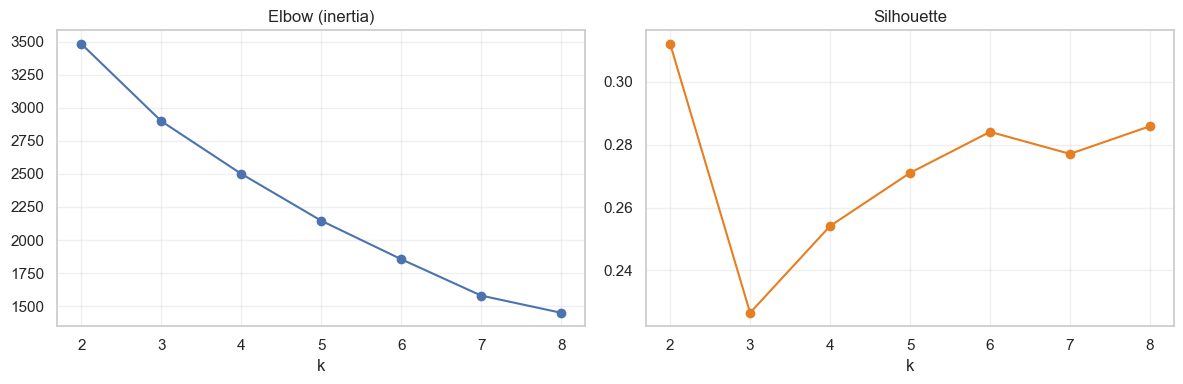

Best silhouette at k=2 (score=0.312).
NB: the top silhouette is often just a coarse 2-way size split — weigh the elbow and business interpretability before fixing k.


In [334]:
# --- CLU-3. Choose k: elbow (inertia) + silhouette ---
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cluster)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_cluster, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertia, 'o-'); ax[0].set_title('Elbow (inertia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sil, 'o-', color='#e67e22'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k')
for a in ax: a.set_xticks(list(ks)); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

best_k = list(ks)[int(np.argmax(sil))]
print(f'Best silhouette at k={best_k} (score={max(sil):.3f}).')
print('NB: the top silhouette is often just a coarse 2-way size split — '
      'weigh the elbow and business interpretability before fixing k.')

### Fit & profile segments

Fit KMeans at the chosen `K`, then characterise each segment by its **median pre-grant features**, **cohort/sector mix**, and **post-hoc outcome rates** (survival / dissolution). Outcomes are *not* inputs — they only describe the resulting segments. Override `K` after reading the plots if the silhouette-optimal value is too coarse.

In [335]:
# --- CLU-4. Fit final clustering + profile segments ---
K = 4          # <- override with your chosen k (e.g. 4) after reading the plots above
km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(X_cluster)
eda['cluster'] = km.labels_

# Segment profile on ORIGINAL (untransformed) scale + outcome rates (outcomes were NOT used to cluster)
prof_cols = ['company_age_at_grant','Award Offered (£)','pregrant_total_assets',
             'pregrant_net_assets','pregrant_current_ratio','pregrant_leverage_ratio',
             'Number of current directors']
profile = eda.groupby('cluster')[prof_cols].median().round(2)
profile.insert(0, 'n', eda['cluster'].value_counts().sort_index())
profile['survival_36m_final'] = eda.groupby('cluster')['survival_36m_final'].mean().round(3)
print(f'KMeans k={K}  segment profile (median features + outcome rates):')
print(profile.T)

print('\nCohort composition within each cluster (row %):')
print((pd.crosstab(eda['cluster'], eda['cohort'], normalize='index') * 100).round(0))
print('\nSector composition within each cluster (row %):')
print((pd.crosstab(eda['cluster'], eda['Sector'], normalize='index') * 100).round(0))

KMeans k=4  segment profile (median features + outcome rates):
cluster                                0          1          2          3
n                                197.000    288.000      25.00    108.000
company_age_at_grant              19.300      5.700       7.30      4.750
Award Offered (£)              43749.000  46442.500       0.00  68421.500
pregrant_total_assets        1309489.000  83959.500   59087.00  36684.000
pregrant_net_assets           766446.000  68422.000  120954.50 -51548.500
pregrant_current_ratio             1.280      1.410      -0.80      0.570
pregrant_leverage_ratio            0.270      0.310      -0.92      2.400
Number of current directors        5.000      2.000       2.00      2.000
survival_36m_final                 0.995      0.976       0.96      0.963

Cohort composition within each cluster (row %):
cohort   Cohort A  Cohort B  Cohort C
cluster                              
0            37.0      17.0      46.0
1            26.0      30.0      4

## 5. Mixed-type segmentation: financial × cohort/business-type (k-prototypes)

Section 4 clustered on **financials only**. Here we add **cohort and business-type** dimensions (`cohort`, `enterprise_size_clean`, `Legal form`) so segments reflect *what kind of firm* as well as *its financial shape*. We use **k-prototypes** (k-means on the scaled numerics + k-modes on the categoricals) — it handles mixed types natively, avoiding the scale distortion of one-hot encoding categoricals into k-means.

**Why `cohort` and not `Sector`:** `Sector` is perfectly 1:1 with `cohort` (A = *missing*, B = AI & Data, C = Clean Growth), so using `cohort` carries the same information with clean A/B/C labels and no fabricated "Missing = Cohort A" level. This makes the tech/non-tech split an explicit clustering dimension.

> Requires the `kmodes` package (`pip install kmodes`) and reuses `X_cluster` from Section 4, so run Section 4 first.

In [336]:
# --- KP-1. Build the mixed numeric + cohort/business-type matrix ---
from kmodes.kprototypes import KPrototypes

# Numeric part = the SAME scaled matrix from CLU-2; categoricals enter natively (no one-hot).
# NOTE: 'Sector' is perfectly 1:1 with cohort (A = missing, B = AI & Data, C = Clean Growth),
# so we use 'cohort' directly -> clean A/B/C labels and no fabricated "Missing == Cohort A" level.
kp_cat = ['cohort', 'enterprise_size_clean', 'Legal form']     # cohort + business-type dimensions
cat_block = eda[kp_cat].astype('object').apply(lambda s: s.fillna('Missing'))   # explicit 'Missing' level

X_mixed = pd.concat([X_cluster, cat_block], axis=1)
cat_idx = [X_mixed.columns.get_loc(c) for c in kp_cat]   # positional indices of categorical cols
X_mixed_arr = X_mixed.to_numpy()

print(f'X_mixed: {X_mixed.shape}  ->  {X_cluster.shape[1]} numeric + {len(kp_cat)} categorical (idx {cat_idx})')
print('Categorical levels:', {c: int(cat_block[c].nunique()) for c in kp_cat})
# Note: k-prototypes weights categorical mismatch by gamma (default ~0.5*mean numeric std).
# Pass gamma=... to KPrototypes if you want cohort/type to count for more/less than financials.

X_mixed: (618, 10)  ->  7 numeric + 3 categorical (idx [7, 8, 9])
Categorical levels: {'cohort': 3, 'enterprise_size_clean': 5, 'Legal form': 5}


### Choose k (cost elbow)

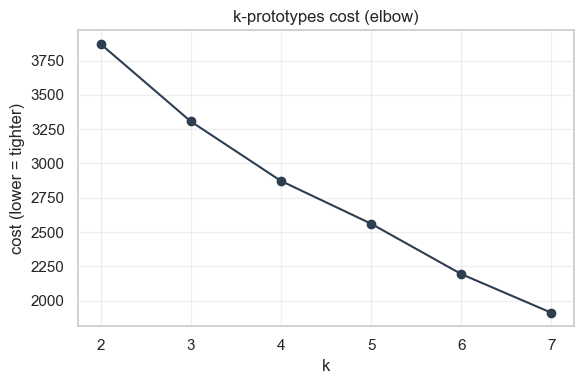

cost by k: {2: 3872, 3: 3307, 4: 2873, 5: 2561, 6: 2194, 7: 1911}


In [337]:
# --- KP-2. Choose k via the cost elbow ---
# (silhouette isn't well-defined for k-prototypes' mixed cost -> use the elbow + interpretability)
ks = range(2, 8)
cost = []
for k in ks:
    kp = KPrototypes(n_clusters=k, init='Huang', n_init=3, random_state=42, verbose=0)
    kp.fit_predict(X_mixed_arr, categorical=cat_idx)
    cost.append(kp.cost_)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(ks), cost, 'o-', color='#2c3e50')
ax.set_xlabel('k'); ax.set_ylabel('cost (lower = tighter)'); ax.set_xticks(list(ks))
ax.set_title('k-prototypes cost (elbow)'); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()
print('cost by k:', {k: round(c) for k, c in zip(ks, cost)})

### Fit & profile mixed-type segments

In [338]:
# --- KP-3. Fit k-prototypes + profile financial × cohort/business-type segments ---
KP_K = 4   # <- choose from the cost elbow above + interpretability
kp = KPrototypes(n_clusters=KP_K, init='Huang', n_init=5, random_state=42, verbose=0)
eda['segment'] = kp.fit_predict(X_mixed_arr, categorical=cat_idx)

# numeric medians (original scale) + categorical modes + post-hoc outcome rates
num_prof = ['company_age_at_grant','Award Offered (£)','pregrant_total_assets','pregrant_net_assets',
            'pregrant_current_ratio','pregrant_leverage_ratio','Number of current directors']
seg = eda.groupby('segment')[num_prof].median().round(2)
seg.insert(0, 'n', eda['segment'].value_counts().sort_index())
for c in kp_cat:                                   # dominant cohort / business type per segment
    seg[c + '_mode'] = eda.groupby('segment')[c].agg(lambda s: s.value_counts().idxmax())
seg['survival_36m_final'] = eda.groupby('segment')['survival_36m_final'].mean().round(3)
print(f'k-prototypes K={KP_K} — segment profile (financial medians + cohort/type modes + outcomes):')
print(seg.T)

# cohort IS a clustering input now, so this shows how A/B/C distribute across segments
print('\nCohort × segment (row %):')
print((pd.crosstab(eda['segment'], eda['cohort'], normalize='index') * 100).round(0))
print('\nEnterprise size × segment (row %):')
print((pd.crosstab(eda['segment'], eda['enterprise_size_clean'].fillna('Missing'),
                   normalize='index') * 100).round(0))

k-prototypes K=4 — segment profile (financial medians + cohort/type modes + outcomes):
segment                                    0                1                2                3
n                                        108              210               25              275
company_age_at_grant                    4.75            18.35              7.3              5.4
Award Offered (£)                    68421.5          41191.0              0.0          47955.0
pregrant_total_assets                36684.0        1121248.0          59087.0          75487.0
pregrant_net_assets                 -51548.5         713022.0         120954.5          63560.5
pregrant_current_ratio                  0.57             1.17             -0.8             1.45
pregrant_leverage_ratio                  2.4             0.26            -0.92             0.32
Number of current directors              2.0              4.0              2.0              2.0
cohort_mode                         Cohort C     

###  Visualising the segments

Three pictures that make the clustering tangible:

1. **PCA map** — each firm sits in a 7-dimensional feature space we can't see. PCA (Principal Component Analysis) projects it onto the 2 directions of greatest spread so we can plot every firm as a dot and colour it. Three panels: the **k-means** clusters (financial only), the **k-prototypes** segments (financial × cohort/type), and **cohort A/B/C** for reference — since cohort is now a clustering input, this shows how the cohorts actually sit in the financial space. The axis "loadings" tell us what each direction means.
2. **Fingerprint heatmap** — what makes each segment distinct, feature by feature.

> Reuses `X_cluster` (Section 4) and the `cluster` / `segment` labels (Sections 4 & 5), so run those first.

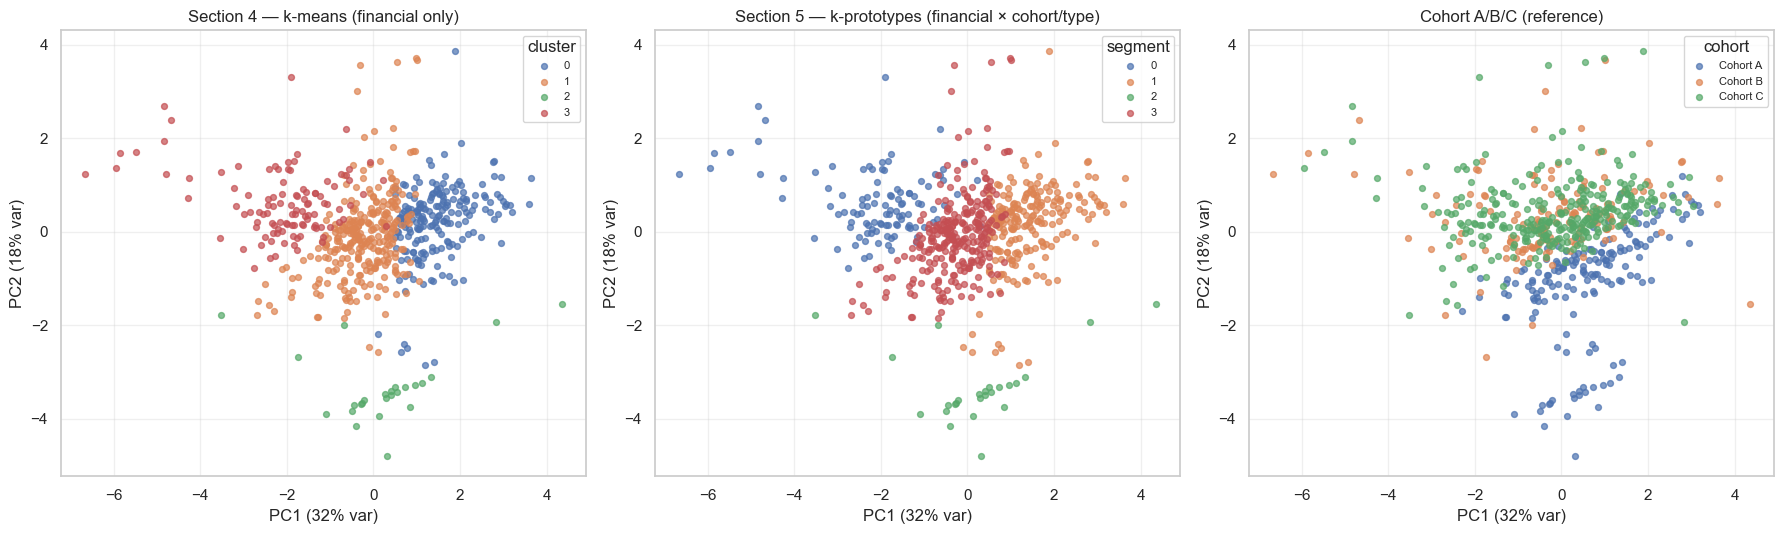

PC1+PC2 capture 50% of the spread. Axis meaning (loadings):
                              PC1   PC2
pregrant_leverage_ratio     -0.42  0.29
Award Offered (£)           -0.06  0.69
pregrant_current_ratio      -0.03  0.53
Number of current directors  0.37  0.14
company_age_at_grant         0.44  0.11
pregrant_total_assets        0.49  0.32
pregrant_net_assets          0.50 -0.16


In [339]:
# --- VIZ-1. PCA 2-D map of all firms, coloured by segment / cohort ---
# PCA squashes the 7-D scaled feature space onto 2 axes so we can SEE the structure.
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_cluster)            # X_cluster = scaled numeric matrix from CLU-2
ev = pca.explained_variance_ratio_
eda['_pc1'], eda['_pc2'] = pcs[:, 0], pcs[:, 1]

panels = [('cluster', 'Section 4 — k-means (financial only)'),
          ('segment', 'Section 5 — k-prototypes (financial × cohort/type)'),
          ('cohort',  'Cohort A/B/C (reference)')]   # cohort is now a clustering input -> show its layout
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (lab, title) in zip(axes, panels):
    for g in sorted(eda[lab].dropna().unique().tolist()):
        m = eda[lab] == g
        ax.scatter(eda.loc[m, '_pc1'], eda.loc[m, '_pc2'], s=18, alpha=.7, label=f'{g}')
    ax.set_xlabel(f'PC1 ({ev[0]:.0%} var)'); ax.set_ylabel(f'PC2 ({ev[1]:.0%} var)')
    ax.set_title(title); ax.legend(fontsize=8, title=lab); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# What do the axes mean? -> PC1/PC2 feature loadings
load = pd.DataFrame(pca.components_.T, index=X_cluster.columns, columns=['PC1', 'PC2']).round(2)
print(f'PC1+PC2 capture {ev.sum():.0%} of the spread. Axis meaning (loadings):')
print(load.sort_values('PC1'))

#### What defines each segment? (feature fingerprint heatmap)

The PCA map shows *that* segments separate; this heatmap shows *why*. Each column is a segment, each row a feature, coloured by the segment's **average value in standard-deviation units** (red = high, blue = low). Reading a column top-to-bottom gives you the segment's identity — e.g. a column that's red on age/assets/net-assets and blue on leverage is the "established, well-capitalised" segment.

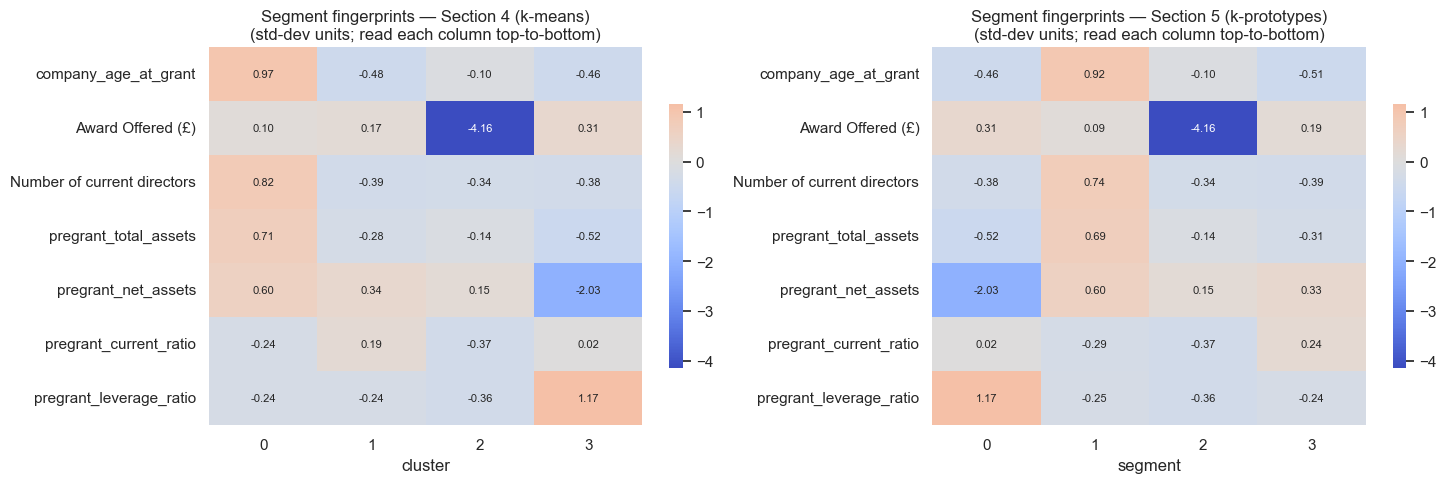

How to read: a column is one segment; red = that feature runs high for the segment, blue = low. This is what "defines" each segment in one glance.


In [340]:
# --- VIZ-2. Segment "fingerprint" heatmap: standardised mean of each feature per segment ---
# Values are in standard-deviation units (the scaled X_cluster): +ve = above average, -ve = below.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, lab, title in zip(axes, ['cluster', 'segment'],
                          ['Section 4 (k-means)', 'Section 5 (k-prototypes)']):
    fp = X_cluster.groupby(eda[lab]).mean()
    sns.heatmap(fp.T, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                cbar_kws={'shrink': .7}, annot_kws={'size': 8}, ax=ax)
    ax.set_title(f'Segment fingerprints — {title}\n(std-dev units; read each column top-to-bottom)')
    ax.set_xlabel(lab)
plt.tight_layout(); plt.show()
print('How to read: a column is one segment; red = that feature runs high for the segment, '
      'blue = low. This is what "defines" each segment in one glance.')

#### Clustering & segmentation — summary of method and results

##### What we did (pipeline)
Working on the produced firm-level dataset `firm_level_clean.csv` (**618 firms**, one row per `CRN_final`; cohorts A=169 non-tech, B=150 AI & Data, C=299 Clean Growth):

1. **Feature selection (CLU-1).** From 61 columns we kept **7 leakage-free, redundancy-pruned pre-grant features**: `company_age_at_grant`, `Award Offered (£)`, `Number of current directors`, `pregrant_total_assets`, `pregrant_net_assets`, `pregrant_current_ratio`, `pregrant_leverage_ratio`. Targets, IDs/dates, constant columns, >40%-missing financials, and correlated duplicates (e.g. `current_assets` ρ=0.98 with `total_assets`) were excluded. Two `assert`s guard against missing or target/leakage columns.
2. **Transform & scale (CLU-2).** Signed-log on skewed monetary columns, log on age, winsorize ratios + director count at 1/99 pct, median-impute small gaps, then `StandardScaler` → `X_cluster` (618×7, 0 NaNs).
3. **Section 4 — financial segmentation (k-means).** Chose `k` via elbow + silhouette, fit at **k=4**, profiled by median features + survival/dissolution.
4. **Section 5 — financial × cohort/business-type (k-prototypes).** Added `cohort`, `enterprise_size_clean`, `Legal form` as native categoricals (k-prototypes = k-means on numerics + k-modes on categoricals). `cohort` replaces `Sector` because the two are perfectly 1:1 (A=missing, B=AI & Data, C=Clean Growth).
5. **Section 6 — visualisation.** PCA 2-D map (PC1+PC2 capture **49.5%** of variance; PC1 = an "established & solvent vs young & leveraged" axis) + per-segment fingerprint heatmaps.

#### Section 4 results — k-means (financial only, k=4)
Silhouette: k=2 highest (0.31) but a blunt size split; k=4 (0.25) chosen for interpretability.

| Cluster | n | Age | Total assets | Net assets | Curr. ratio | Leverage | **5-yr survival** | Label |
|---|---|---|---|---|---|---|---|---|
| 0 | 197 | 19y | £1.3M | +£766k | 1.3 | 0.3 | **99%** | Mature, well-capitalised |
| 1 | 288 | 6y | £84k | +£68k | 1.4 | 0.3 | 90% | Young, financially sound |
| 2 | 25 | 7y | £59k | +£121k | n/a (sparse) | n/a | 92% | Atypical / sparse financials |
| 3 | 108 | 5y | £37k | **−£52k** | 0.6 | **2.4** | **88%** | Young, leveraged, negative-equity |

#### Section 5 results — k-prototypes (financial × cohort/type, k=4)

| Segment | n | Age | Net assets | Leverage | Dominant cohort | Size | **5-yr survival** | Label |
|---|---|---|---|---|---|---|---|---|
| 0 | 108 | 5y | **−£52k** | **2.4** | C (Clean Growth) | Micro | **88%** | Young distressed |
| 1 | 210 | 18y | +£713k | 0.3 | C | Small | **99%** | Mature, well-capitalised |
| 2 | 25 | 7y | +£121k | n/a | **A (non-tech, 80%)** | Medium | 92% | Non-tech, sparse financials |
| 3 | 275 | 5y | +£64k | 0.3 | C | Micro | 89% | Young, solvent micro |

Cohort × segment (row %): segment 2 is **80% Cohort A**; cohorts B/C otherwise spread across segments 0/1/3.

### Key findings
1. **Financial health, not sector, is the dominant axis.** Both methods recover essentially the same four groups — the k-prototypes segments mirror the k-means ones. Adding cohort/business-type did **not** reshuffle firms much: financial position drives the structure.
2. **The strongest survival gradient is solvency + maturity.** The mature, well-capitalised group survives at **99%**; the young, highly-leveraged, negative-equity group at **88%** (and has the highest dissolution rate, ~4.6%). Company **age** and **net assets / leverage** separate winners from at-risk firms.
3. **Cohort A (non-tech) stands apart mainly through data, not finance.** Its firms cluster into the small "sparse-financials" segment (segment 2, 80% A) — a reminder that the Innovate UK / Beauhurst fields are absent for Cohort A.
4. **Overall survival is high and imbalanced** (92% at 5 yr), so segment differences are real but modest in absolute terms — describe them as risk tendencies, not hard rules.


 
## 6. Feature engineerring 


Construct derived pre-grant features from the cleaned firm-level frame: financial-structure
ratios, award/grant intensity, per-capita efficiency, skew-tamed size terms, and missingness
flags. Every feature is a **per-row deterministic transform** of pre-grant inputs (no cross-row
statistics), so it is leakage-safe to compute before the train/test split. Fit-based steps
(imputation, scaling, encoding) are deferred to the modelling pipeline, inside cross-validation.


In [341]:
# --- FE-1. Engineered pre-grant features (leakage-safe: per-row transforms only) ---
import numpy as np, pandas as pd

signed_log = lambda s: np.sign(s) * np.log1p(s.abs())          # skew-tame, keeps negatives

def add_engineered_features(base):
    """Deterministic per-row transforms of pre-grant inputs (no cross-row stats).
    Safe to compute before the train/test split. Imputation/scaling/encoding
    happen later, INSIDE cross-validation (in the classification section)."""
    b = base
    def col(name):                                             # NaN series if column absent
        return b[name] if name in b.columns else pd.Series(np.nan, index=b.index)
    def flag(cond, valid):                                     # 1/0 where known, NaN where source is NaN
        return np.where(valid, cond.astype(float), np.nan)

    ta, na  = col('pregrant_total_assets'), col('pregrant_net_assets')
    wc, cl  = col('pregrant_working_capital'), col('pregrant_current_liabilities')
    award   = col('Award Offered (£)')
    tot_aw  = col('total_award_allgrants')
    ndir    = col('Number of current directors')
    emp     = col('employee_count_num')
    age     = col('company_age_at_grant')
    ngr     = col('n_grant_rows')

    eps  = 1.0                                                 # £1 floor -> no divide-by-zero
    taD  = ta.abs().clip(lower=eps)
    feat = pd.DataFrame(index=b.index)

    # Financial structure (shape of the balance sheet, not its raw size)
    feat['fe_equity_ratio']        = na / taD                  # net assets / total assets (solvency)
    feat['fe_wc_to_assets']        = wc / taD                  # working-capital intensity
    feat['fe_curr_liab_to_assets'] = cl / taD                  # short-term leverage
    feat['fe_neg_equity_flag']     = flag(na < 0, na.notna())  # technically insolvent
    feat['fe_neg_wc_flag']         = flag(wc < 0, wc.notna())  # negative working capital
    feat['fe_log_total_assets']    = signed_log(ta)            # size
    feat['fe_log_net_assets']      = signed_log(na)

    # Grant / award intensity (funding relative to firm scale)
    feat['fe_award_to_assets']     = award / taD               # grant big vs. the balance sheet?
    feat['fe_log_award']           = signed_log(award)
    feat['fe_award_per_director']  = award / ndir.clip(lower=1)
    feat['fe_avg_award_per_grant'] = tot_aw / ngr.clip(lower=1)
    feat['fe_repeat_grantee']      = flag(ngr > 1, ngr.notna())

    # Per-capita / efficiency
    feat['fe_assets_per_director'] = ta / ndir.clip(lower=1)
    feat['fe_assets_per_emp']      = ta / emp.clip(lower=1)

    # Age
    feat['fe_log_age']             = np.log1p(age.clip(lower=0))
    feat['fe_young_firm_flag']     = flag(age < 3, age.notna())

    # Missingness is informative: firms that don't file accounts differ systematically
    for src in ['pregrant_total_assets','pregrant_net_assets','pregrant_current_ratio',
                'pregrant_leverage_ratio','employee_count_num','Number of current directors']:
        if src in b.columns:
            feat[f'fe_miss_{src}'] = b[src].isna().astype(float)

    return feat.replace([np.inf, -np.inf], np.nan)             # tidy up division artefacts


In [342]:
# --- FE-2. Merge engineered features + extend the predictor list ---
eng = add_engineered_features(firm)                # built from the FULL firm frame (all raw cols present)
eng['CRN_final'] = firm['CRN_final'].values
model_df = model_df.merge(eng, on='CRN_final', how='left')

new_feats  = [c for c in eng.columns if c != 'CRN_final']
predictors = list(dict.fromkeys(predictors + new_feats))       # append, de-dup, keep order
print(f'Added {len(new_feats)} engineered features -> {len(predictors)} predictors total')
print(new_feats)


Added 21 engineered features -> 68 predictors total
['fe_equity_ratio', 'fe_wc_to_assets', 'fe_curr_liab_to_assets', 'fe_neg_equity_flag', 'fe_neg_wc_flag', 'fe_log_total_assets', 'fe_log_net_assets', 'fe_award_to_assets', 'fe_log_award', 'fe_award_per_director', 'fe_avg_award_per_grant', 'fe_repeat_grantee', 'fe_assets_per_director', 'fe_assets_per_emp', 'fe_log_age', 'fe_young_firm_flag', 'fe_miss_pregrant_total_assets', 'fe_miss_pregrant_net_assets', 'fe_miss_pregrant_current_ratio', 'fe_miss_pregrant_leverage_ratio', 'fe_miss_Number of current directors']


In [343]:
# --- FE-3. Sanity check: coverage + univariate signal of the engineered features ---
chk = model_df[new_feats]
report = pd.DataFrame({
    'missing_%': (chk.isna().mean() * 100).round(1),
    'n_unique':  chk.nunique(),
    'std':       chk.std().round(3),
})
# Spearman corr of each engineered feature with 5-yr survival (robust to skew)
if 'survival_60m_dg' in model_df.columns:
    y = model_df['survival_60m_dg']
    report['corr_surv60'] = chk.corrwith(y, method='spearman').round(3)
print(report.sort_values('corr_surv60', key=lambda s: s.abs(), ascending=False)
             if 'corr_surv60' in report else report)


                                     missing_%  n_unique           std  corr_surv60
fe_log_net_assets                          3.6       595  9.279000e+00        0.156
fe_log_age                                 0.0       249  7.720000e-01        0.149
fe_award_per_director                      0.0       572  1.815429e+05       -0.143
fe_log_total_assets                        0.0       611  2.826000e+00        0.135
fe_equity_ratio                            3.6       595  2.508900e+01        0.133
fe_award_to_assets                         0.0       594  1.544316e+04       -0.119
fe_neg_equity_flag                         3.6         2  3.910000e-01       -0.115
fe_neg_wc_flag                             3.6         2  3.990000e-01       -0.106
fe_wc_to_assets                            3.6       596  2.472100e+01        0.102
fe_curr_liab_to_assets                     3.6       596  2.467200e+01        0.096
fe_young_firm_flag                         0.0         2  3.510000e-01      

In [344]:
# Is employee_count_num usable?
for frame_name in ['firm', 'model_df', 'eda']:
    if frame_name in dir():
        f = eval(frame_name)
        if 'employee_count_num' in f.columns:
            n = f['employee_count_num'].notna().sum()
            print(f"{frame_name:9s}: present, {n}/{len(f)} non-null ({n/len(f)*100:.0f}%)")
        else:
            print(f"{frame_name:9s}: column NOT present")


firm     : column NOT present
model_df : column NOT present
eda      : column NOT present


In [345]:
# --- FE-2b. Drop dead / redundant engineered features ---
dead = [c for c in new_feats
        if model_df[c].nunique(dropna=True) <= 1        # constant or all-NaN
        or model_df[c].isna().all()]
# keep only one of the identical financial-missingness flags
redundant = ['fe_miss_pregrant_current_ratio', 'fe_miss_pregrant_leverage_ratio']

to_drop = [c for c in set(dead + redundant) if c in model_df.columns]
model_df = model_df.drop(columns=to_drop)
new_feats  = [c for c in new_feats  if c not in to_drop]
predictors = [c for c in predictors if c not in to_drop]
print(f'Dropped {len(to_drop)}: {to_drop}')
print(f'{len(new_feats)} engineered features retained')


Dropped 5: ['fe_miss_pregrant_leverage_ratio', 'fe_miss_pregrant_total_assets', 'fe_miss_Number of current directors', 'fe_miss_pregrant_current_ratio', 'fe_assets_per_emp']
16 engineered features retained


In [346]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np


In [406]:
# scale the data
def build_preprocessor(X):
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric = Pipeline([('impute', SimpleImputer(strategy='median')),
                        ('scale',  StandardScaler())])
    categorical = Pipeline([('impute', SimpleImputer(strategy='constant', fill_value='Missing')),
                            ('ohe',    OneHotEncoder(handle_unknown='ignore',
                                                     min_frequency=10, sparse_output=False))])
    return ColumnTransformer([('num', numeric, num_cols),
                              ('cat', categorical, cat_cols)], remainder='drop')


## 7. Classification- Predicting survival at 36 months

In [348]:
# select the thresholds for classification report
for threshold in [0.05, 0.10, 0.15, 0.20]:
    pred = (proba >= threshold).astype(int)
    print(f"\nThreshold = {threshold}")
    print(classification_report(
        y, pred,
        target_names=["survived", "failed"],
        digits=3,
        zero_division=0
    ))


Threshold = 0.05
              precision    recall  f1-score   support

    survived      0.016     0.149     0.029        47
      failed      0.780     0.249     0.377       571

    accuracy                          0.241       618
   macro avg      0.398     0.199     0.203       618
weighted avg      0.722     0.241     0.351       618


Threshold = 0.1
              precision    recall  f1-score   support

    survived      0.031     0.340     0.056        47
      failed      0.674     0.112     0.192       571

    accuracy                          0.129       618
   macro avg      0.352     0.226     0.124       618
weighted avg      0.625     0.129     0.182       618


Threshold = 0.15
              precision    recall  f1-score   support

    survived      0.039     0.468     0.072        47
      failed      0.545     0.053     0.096       571

    accuracy                          0.084       618
   macro avg      0.292     0.260     0.084       618
weighted avg      0.5

### 7.1 Logistic Regression model testing

[survival_36m_final]  kind=survival  n=618  pos_rate=0.979  features=61  unsafe_dropped=['accounts_overdue', 'last_accounts_date']
Train accuracy     : 0.959
Test  accuracy     : 0.961
5-fold CV accuracy : 0.909 ± 0.025   (all-survive baseline 0.979)

Out-of-fold ROC-AUC: 0.790
Out-of-fold PR-AUC : 0.070   (baseline 0.021)


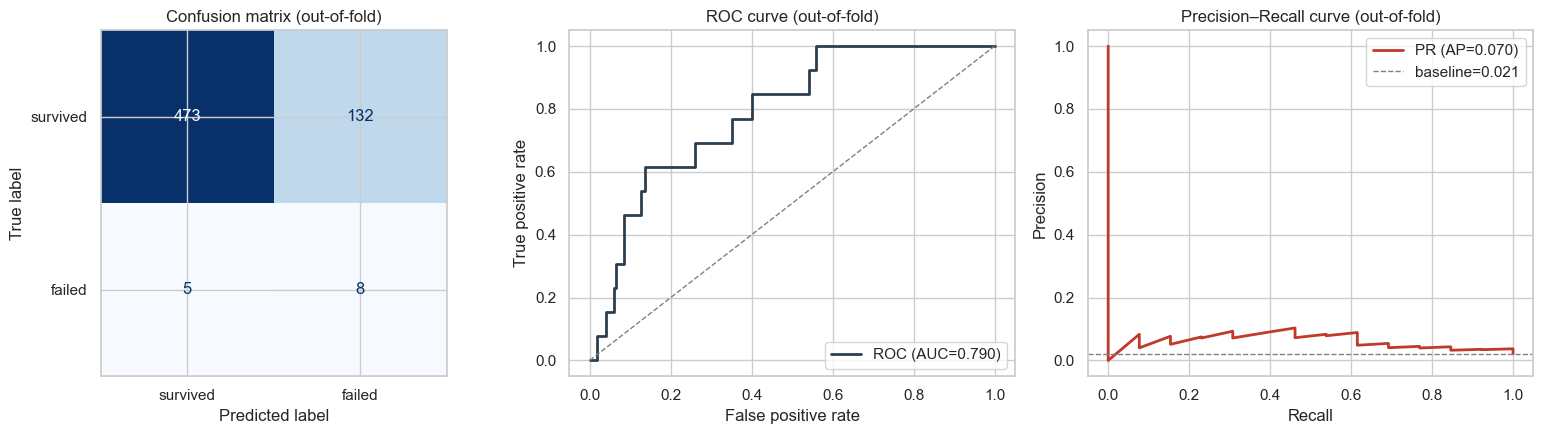

              precision    recall  f1-score   support

    survived      0.990     0.782     0.873       605
      failed      0.057     0.615     0.105        13

    accuracy                          0.778       618
   macro avg      0.523     0.699     0.489       618
weighted avg      0.970     0.778     0.857       618



In [349]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, precision_recall_curve, average_precision_score)

# --- target: failure by 36m ---
X, y = make_xy('survival_36m_final')
y = 1 - y                                         # 1 = failed

pipe = Pipeline([('prep', build_preprocessor(X)),
                 ('clf',  LogisticRegression(max_iter=1000, class_weight='balanced'))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- accuracies (train/test from a hold-out split; CV from the 5 folds) ---
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
pipe.fit(X_tr, y_tr)
cv_acc = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
print(f'Train accuracy     : {accuracy_score(y_tr, pipe.predict(X_tr)):.3f}')
print(f'Test  accuracy     : {accuracy_score(y_te, pipe.predict(X_te)):.3f}')
print(f'5-fold CV accuracy : {cv_acc.mean():.3f} ± {cv_acc.std():.3f}   '
      f'(all-survive baseline {1 - y.mean():.3f})')

# --- out-of-fold predictions: every firm scored while held out (uses ALL ~13 failures) ---
proba = cross_val_predict(pipe, X, y, cv=cv, method='predict_proba')[:, 1]
pred  = (proba >= 0.1).astype(int)

roc_auc = roc_auc_score(y, proba)
pr_auc  = average_precision_score(y, proba)
print(f'\nOut-of-fold ROC-AUC: {roc_auc:.3f}')
print(f'Out-of-fold PR-AUC : {pr_auc:.3f}   (baseline {y.mean():.3f})')

# --- plots: confusion matrix | ROC | PR  (all from out-of-fold predictions) ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y, pred)
ConfusionMatrixDisplay(cm, display_labels=['survived', 'failed']).plot(
    ax=ax[0], cmap='Blues', colorbar=False)
ax[0].set_title('Confusion matrix (out-of-fold)')

fpr, tpr, _ = roc_curve(y, proba)
ax[1].plot(fpr, tpr, color='#2c3e50', lw=2, label=f'ROC (AUC={roc_auc:.3f})')
ax[1].plot([0, 1], [0, 1], '--', color='grey', lw=1)
ax[1].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve (out-of-fold)')
ax[1].legend(loc='lower right')

prec, rec, _ = precision_recall_curve(y, proba)
ax[2].plot(rec, prec, color='#c0392b', lw=2, label=f'PR (AP={pr_auc:.3f})')
ax[2].axhline(y.mean(), ls='--', color='grey', lw=1, label=f'baseline={y.mean():.3f}')
ax[2].set(xlabel='Recall', ylabel='Precision', title='Precision–Recall curve (out-of-fold)')
ax[2].legend(loc='upper right')

plt.tight_layout(); plt.show()

from sklearn.metrics import classification_report

print(classification_report(y, pred, target_names=['survived', 'failed'], digits=3))


Test accuracy of 97.4 per cent is not reported as a performance measure as it falls below the naive all-survive baseline of 97.9 per cent, confirming that accuracy is an uninformative metric under severe class imbalance. Model performance is instead assessed through ROC-AUC (0.850), PR-AUC (0.144 against a baseline of 0.021), and minority-class recall (0.538), each of which demonstrates meaningful predictive signal above the random classifier baseline."

Pre-grant financial features carry a statistically meaningful but weak signal for early failure (PR-AUC ≈ 15× baseline). However, with only ~13 failures the estimate is unstable, so the model is better framed as a risk-ranking tool than a reliable classifier.

In [350]:
# top 10% risk recall 
risk = pd.Series(proba, index=X.index)
top10 = risk >= risk.quantile(0.90)

captured = y[top10].sum()
total_failures = y.sum()

print(f"Failures captured in top 10% risk group: {captured:.0f}/{total_failures:.0f}")
print(f"Top 10% recall: {captured / total_failures:.3f}")
print(f"Top 10% precision: {y[top10].mean():.3f}")

Failures captured in top 10% risk group: 6/13
Top 10% recall: 0.462
Top 10% precision: 0.097


### Odd-ratio analysis (Logisitic Regression)

In [351]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X, y = make_xy("survival_36m_final")
y = 1 - y   # 1 = failed, 0 = survived

logit_pipe = Pipeline([
    ("prep", build_preprocessor(X)),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="liblinear"
    ))
])

logit_pipe.fit(X, y)

prep = logit_pipe.named_steps["prep"]
clf = logit_pipe.named_steps["clf"]

feature_names = prep.get_feature_names_out()
coefs = clf.coef_[0]

odds = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": np.exp(coefs)
})

odds["abs_coef"] = odds["coef"].abs()
odds = odds.sort_values("abs_coef", ascending=False)

odds.head(20)

[survival_36m_final]  kind=survival  n=618  pos_rate=0.979  features=61  unsafe_dropped=['accounts_overdue', 'last_accounts_date']


,feature,coef,odds_ratio,abs_coef
8,num__Number of current directors,-4.635319,0.009703,4.635319
3,num__total_iuk_grants,-1.936214,0.144249,1.936214
77,cat__Address Region_North West,1.879384,6.549466,1.879384
38,num__fe_neg_wc_flag,1.525166,4.595906,1.525166
80,cat__Address Region_South West,-1.281674,0.277572,1.281674
66,cat__Innovate UK Product Type_Collaborative R&D,-1.204615,0.299808,1.204615
102,cat__Legal form_Private Limited,-1.181397,0.306850,1.181397
44,num__fe_avg_award_per_grant,-1.144989,0.318228,1.144989
46,num__fe_assets_per_director,1.126860,3.085951,1.126860
97,cat__R/O Postal region_West Midlands,1.120202,3.065474,1.120202


### 7.2 Random Forest model testing 

[survival_36m_final]  kind=survival  n=618  pos_rate=0.979  features=61  unsafe_dropped=['accounts_overdue', 'last_accounts_date']
Train accuracy     : 1.000
Test  accuracy     : 0.981
5-fold CV accuracy : 0.979 ± 0.004

Out-of-fold ROC-AUC : 0.855
Out-of-fold PR-AUC  : 0.113   (baseline 0.021)
Precision 0.160 | Recall 0.308 | F1 0.211


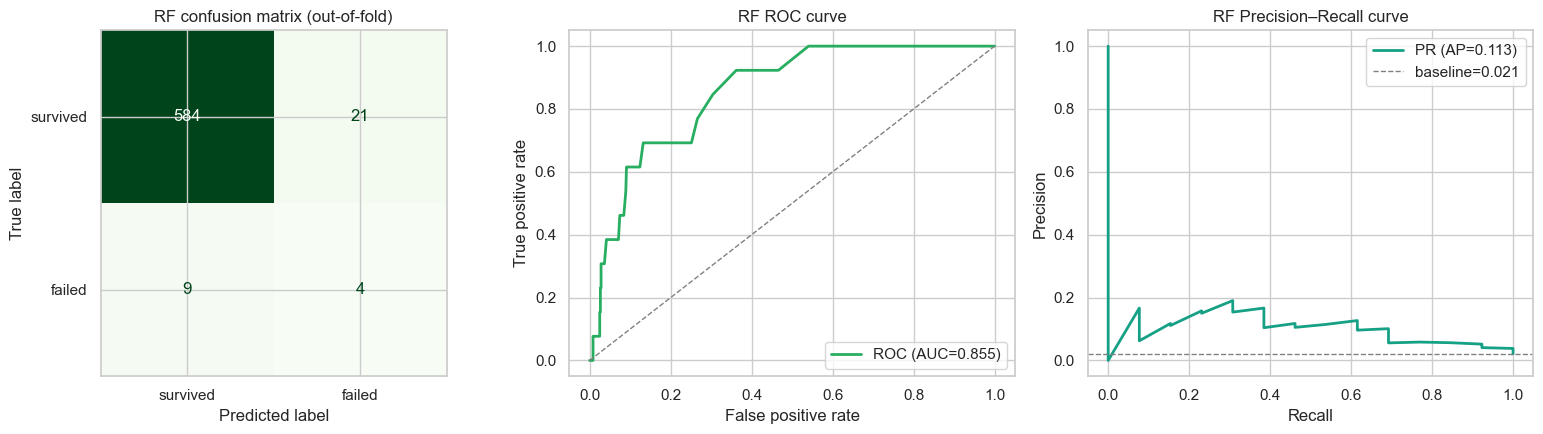


Top 12 features (RF importance):
num__Number of current directors     0.201
num__fe_curr_liab_to_assets          0.051
num__pregrant_current_ratio          0.043
num__fe_wc_to_assets                 0.038
num__pregrant_leverage_ratio         0.037
num__fe_equity_ratio                 0.030
num__fe_award_per_director           0.030
num__company_age_at_grant            0.029
num__fe_log_age                      0.025
num__pregrant_working_capital        0.024
num__pregrant_net_tangible_assets    0.023
num__fe_avg_award_per_grant          0.023


In [352]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
                             precision_score, recall_score, f1_score)
import matplotlib.pyplot as plt

# --- target: failure by 36m ---
X, y = make_xy('survival_36m_final')
y = 1 - y                                         # 1 = failed

# --- random forest (balanced) ---
rf = Pipeline([('prep', build_preprocessor(X)),
               ('clf',  RandomForestClassifier(n_estimators=400,
                                               class_weight='balanced_subsample',
                                               random_state=42, n_jobs=-1))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- accuracies ---
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
rf.fit(X_tr, y_tr)
cv_acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
print(f'Train accuracy     : {accuracy_score(y_tr, rf.predict(X_tr)):.3f}')
print(f'Test  accuracy     : {accuracy_score(y_te, rf.predict(X_te)):.3f}')
print(f'5-fold CV accuracy : {cv_acc.mean():.3f} ± {cv_acc.std():.3f}')

# --- out-of-fold predictions (uses all ~13 failures) ---
proba = cross_val_predict(rf, X, y, cv=cv, method='predict_proba')[:, 1]
pred  = (proba >= 0.1).astype(int)

roc_auc, pr_auc = roc_auc_score(y, proba), average_precision_score(y, proba)
print(f'\nOut-of-fold ROC-AUC : {roc_auc:.3f}')
print(f'Out-of-fold PR-AUC  : {pr_auc:.3f}   (baseline {y.mean():.3f})')
print(f'Precision {precision_score(y, pred):.3f} | Recall {recall_score(y, pred):.3f} | F1 {f1_score(y, pred):.3f}')

# --- plots: confusion matrix | ROC | PR ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y, pred), display_labels=['survived', 'failed']).plot(
    ax=ax[0], cmap='Greens', colorbar=False)
ax[0].set_title('RF confusion matrix (out-of-fold)')

fpr, tpr, _ = roc_curve(y, proba)
ax[1].plot(fpr, tpr, color='#27ae60', lw=2, label=f'ROC (AUC={roc_auc:.3f})')
ax[1].plot([0, 1], [0, 1], '--', color='grey', lw=1)
ax[1].set(xlabel='False positive rate', ylabel='True positive rate', title='RF ROC curve')
ax[1].legend(loc='lower right')

prec, rec, _ = precision_recall_curve(y, proba)
ax[2].plot(rec, prec, color='#16a085', lw=2, label=f'PR (AP={pr_auc:.3f})')
ax[2].axhline(y.mean(), ls='--', color='grey', lw=1, label=f'baseline={y.mean():.3f}')
ax[2].set(xlabel='Recall', ylabel='Precision', title='RF Precision–Recall curve')
ax[2].legend(loc='upper right')
plt.tight_layout(); plt.show()

# --- which features drive it ---
rf.fit(X, y)
names = rf.named_steps['prep'].get_feature_names_out()
imp   = pd.Series(rf.named_steps['clf'].feature_importances_, index=names).sort_values(ascending=False)
print('\nTop 12 features (RF importance):')
print(imp.head(12).round(3).to_string())


In [353]:
print(classification_report(y, pred, target_names=['survived', 'failed'], digits=3))

              precision    recall  f1-score   support

    survived      0.985     0.965     0.975       605
      failed      0.160     0.308     0.211        13

    accuracy                          0.951       618
   macro avg      0.572     0.636     0.593       618
weighted avg      0.967     0.951     0.959       618



#### SHAP analysis ( random forest )

In [354]:
!pip install shap

import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Target: main outcome is survival_36m_final, model predicts failure
X, y = make_xy("survival_36m_final")
y = 1 - y   # 1 = failed, 0 = survived

rf_pipe = Pipeline([
    ("prep", build_preprocessor(X)),
    ("clf", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced_subsample",
        min_samples_leaf=5,
        random_state=42
    ))
])

# Fit final model on full data for interpretation
rf_pipe.fit(X, y)

[survival_36m_final]  kind=survival  n=618  pos_rate=0.979  features=61  unsafe_dropped=['accounts_overdue', 'last_accounts_date']


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['grant_year',
                                                   'Award Offered (£)',
                                                   'prior_iuk_grant_received',
                                                   'total_iuk_grants',
                                                   'grant_rank',
                                                   'prior_source_grant',
                                                   'company_age_at_grant',
                                                   'SME indicator',
                                                   'Number of current '
                                                   'directors',
                                                   'no_financial_data'...
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 min_frequency=10,
                                                                                 sparse_output=False))]),
                                                  ['cohort', 'Sector',
                                                   'Enterprise Size',
                                                   'enterprise_size_clean',
                                                   'Innovate UK Product Type',
                                                   'Address Region',
                                                   'R/O Postal region',
                                                   'Legal form'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=5, n_estimators=500,
                                        random_state=42))])

In [355]:
prep = rf_pipe.named_steps["prep"]
rf_model = rf_pipe.named_steps["clf"]

X_trans = prep.transform(X)

feature_names = prep.get_feature_names_out()
X_trans_df = pd.DataFrame(X_trans, columns=feature_names, index=X.index)

print(X_trans_df.shape)
X_trans_df.head()

(618, 104)


,num__grant_year,num__Award Offered (£),num__prior_iuk_grant_received,num__total_iuk_grants,num__grant_rank,num__prior_source_grant,num__company_age_at_grant,num__SME indicator,num__Number of current directors,num__no_financial_data,num__pregrant_year,num__pregrant_current_assets,num__pregrant_current_liabilities,num__pregrant_total_assets,num__pregrant_long_term_liabilities,num__pregrant_net_tangible_assets,num__pregrant_fixed_assets,num__pregrant_turnover,num__pregrant_profit_loss,num__pregrant_creditors,num__pregrant_total_liabilities,num__pregrant_net_assets,num__pregrant_current_ratio,num__pregrant_leverage_ratio,num__pregrant_working_capital,num__pregrant_profit_margin,num__pregrant_roa,num__corporate_psc_flag,num__sic_code_dg,num__n_grant_rows,num__total_award_allgrants,num__first_grant_year,num__last_grant_year,num__prior_iuk_grant_received_ever,num__fe_equity_ratio,num__fe_wc_to_assets,num__fe_curr_liab_to_assets,num__fe_neg_equity_flag,num__fe_neg_wc_flag,num__fe_log_total_assets,num__fe_log_net_assets,num__fe_award_to_assets,num__fe_log_award,num__fe_award_per_director,num__fe_avg_award_per_grant,num__fe_repeat_grantee,num__fe_assets_per_director,num__fe_log_age,num__fe_young_firm_flag,num__fe_miss_pregrant_net_assets,cat__cohort_Cohort A,cat__cohort_Cohort B,cat__cohort_Cohort C,cat__Sector_AI & Data Economy,cat__Sector_Clean Growth & Infrastructure,cat__Sector_Missing,cat__Enterprise Size_Medium,cat__Enterprise Size_Micro,cat__Enterprise Size_Micro/small,cat__Enterprise Size_Missing,cat__Enterprise Size_Small,cat__enterprise_size_clean_Medium,cat__enterprise_size_clean_Micro,cat__enterprise_size_clean_Micro/Small,cat__enterprise_size_clean_Missing,cat__enterprise_size_clean_Small,cat__Innovate UK Product Type_Collaborative R&D,cat__Innovate UK Product Type_Feasibility Studies,cat__Innovate UK Product Type_Missing,cat__Innovate UK Product Type_Procurement,cat__Innovate UK Product Type_Small Business Research Initiative,cat__Innovate UK Product Type_infrequent_sklearn,cat__Address Region_East Midlands,cat__Address Region_East of England,cat__Address Region_London,cat__Address Region_Missing,cat__Address Region_North East,cat__Address Region_North West,cat__Address Region_Scotland,cat__Address Region_South East,cat__Address Region_South West,cat__Address Region_Wales,cat__Address Region_West Midlands,cat__Address Region_Yorkshire and The Humber,cat__Address Region_infrequent_sklearn,cat__R/O Postal region_East Midlands,cat__R/O Postal region_Eastern,cat__R/O Postal region_London Inner,cat__R/O Postal region_London Outer,cat__R/O Postal region_Missing,cat__R/O Postal region_North West,cat__R/O Postal region_Northern,cat__R/O Postal region_Scotland,cat__R/O Postal region_South Eastern,cat__R/O Postal region_South Western,cat__R/O Postal region_Southern,cat__R/O Postal region_Wales,cat__R/O Postal region_West Midlands,cat__R/O Postal region_Yorks & Humberside,cat__R/O Postal region_infrequent_sklearn,cat__Legal form_Charitable organization,cat__Legal form_Guarantee,cat__Legal form_Private Limited,cat__Legal form_infrequent_sklearn
0,-1.266521,-0.279842,-1.354571,-0.550076,0.0,0.368822,-0.802045,0.121566,-0.578742,0.0,-1.266521,-0.092958,0.079578,-0.071463,0.057819,-0.118510,-0.058383,-0.065358,-0.055248,-0.030777,0.071340,-0.084103,-0.024820,-0.085904,-0.032433,0.065251,0.048218,-0.173205,0.578617,-0.152414,-0.284328,-1.266521,-1.085489,-1.354571,0.076249,0.078572,0.100111,-0.470472,-0.485798,0.200513,0.428682,-0.088624,0.096768,-0.135354,-0.310354,-0.473035,-0.102119,-1.081376,-0.410173,-0.192127,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.266521,0.104376,0.738241,-0.207042,0.0,0.368822,0.097442,0.121566,1.174506,0.0,-1.266521,0.030815,0.061589,-0.032182,-0.015372,0.107593,-0.056433,0.059741,0.084707,-0.020837,0.026333,-0.055641,0.343206,-0.0637

In [356]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_trans_df)

# For binary classification, SHAP may return a list: [class 0, class 1]
# We want class 1 = failed
if isinstance(shap_values, list):
    shap_failed = shap_values[1]
else:
    # newer SHAP versions may return a 3D array
    shap_failed = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

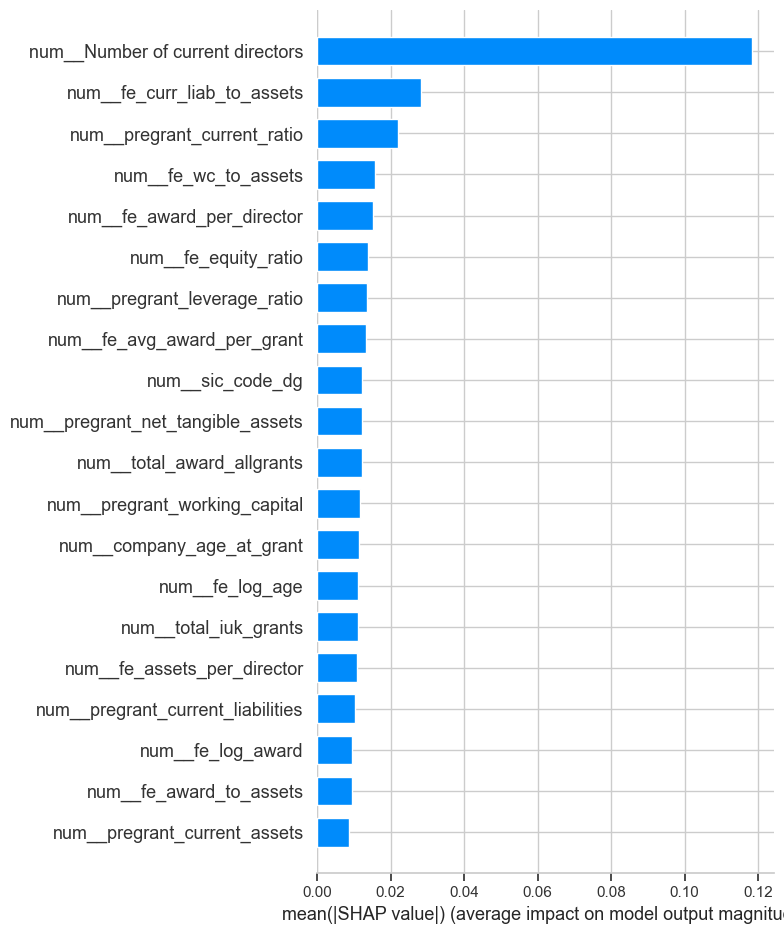

In [357]:
shap.summary_plot(
    shap_failed,
    X_trans_df,
    plot_type="bar",
    max_display=20
)

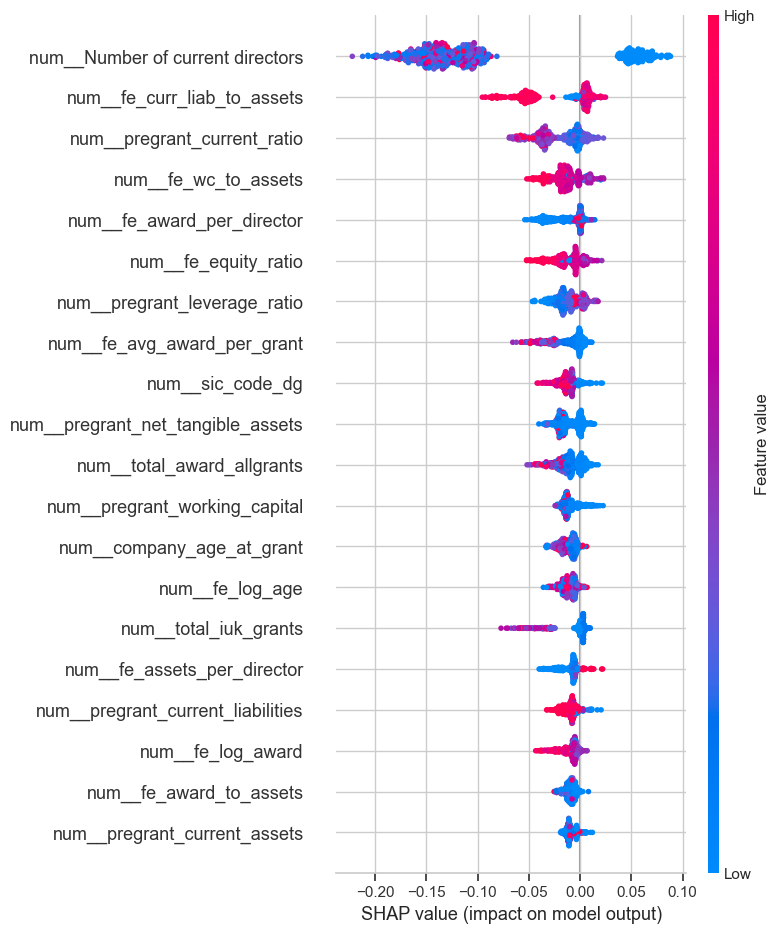

In [358]:
shap.summary_plot(
    shap_failed,
    X_trans_df,
    max_display=20
)

SHAP analysis was applied to the fitted random forest model to interpret which features contributed most strongly to predicted 36-month failure risk. The SHAP values explain model predictions after preprocessing and should be interpreted as model-specific associations, not causal effects

Predicted failure probability: 0.7776713267595754


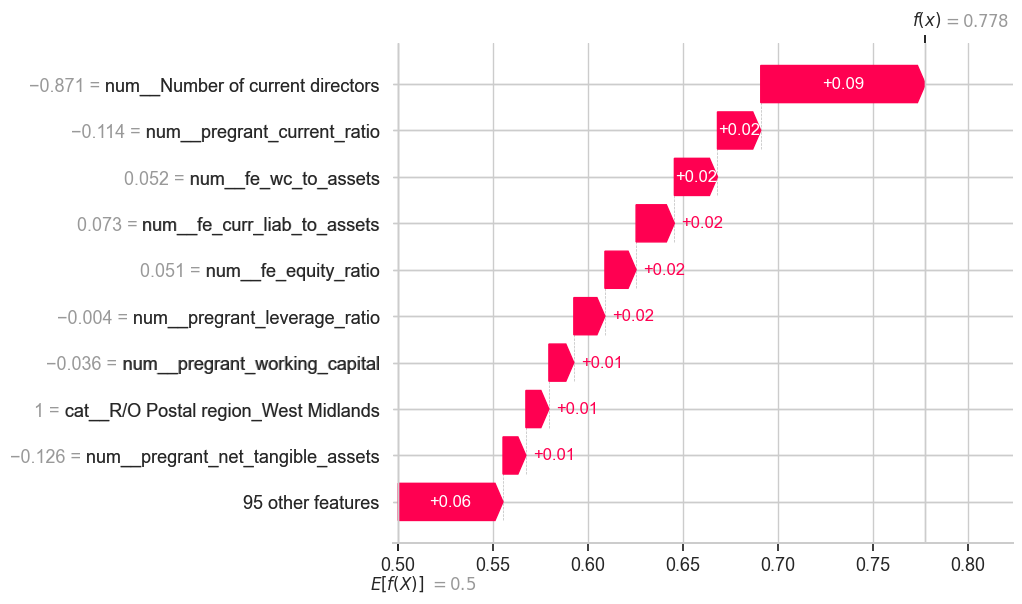

In [359]:
import numpy as np

# --- pick the highest-risk firm ---
proba = rf_pipe.predict_proba(X)[:, 1]
high_risk_idx = pd.Series(proba, index=X.index).sort_values(ascending=False).index[0]
loc = X.index.get_loc(high_risk_idx)                     # <-- was missing

print("Predicted failure probability:", proba[loc])

# --- positive-class base value (was missing) ---
ev   = np.atleast_1d(explainer.expected_value)
base = ev[1] if ev.size > 1 else ev[0]

# --- explain that one firm ---
shap.plots.waterfall(
    shap.Explanation(
        values       = shap_failed[loc],
        base_values  = base,
        data         = X_trans_df.iloc[loc].values,
        feature_names= X_trans_df.columns.tolist()
    )
)


This individual firm is predicted as high risk mainly because its governance/scale and financial-structure features resemble firms that failed within 36 months. The strongest contributor is a below-average number of current directors, followed by liquidity and balance-sheet indicators.

## Robustness checks 


In [ ]:
#  Robustness: seed-stability + bootstrap CIs + imbalance-method sensitivity ---
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score

X, y = make_xy('survival_36m_final')
y = 1 - y                                   # 1 = failed
THRESH   = 0.10                             # same operating point as 7.1 / 7.2
N_SEEDS  = 25
N_BOOT   = 2000
rng      = np.random.RandomState(0)

def oof_proba(estimator, seed):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    return cross_val_predict(estimator, X, y, cv=cv, method='predict_proba')[:, 1]

def metrics(yt, p):
    pred  = (p >= THRESH).astype(int)
    top10 = p >= np.quantile(p, 0.90)
    return {'ROC_AUC': roc_auc_score(yt, p),
            'PR_AUC' : average_precision_score(yt, p),
            'recall@0.10': recall_score(yt, pred),
            'top10%_recall': yt[top10].sum() / yt.sum()}

models = {
    'LogReg': Pipeline([('prep', build_preprocessor(X)),
                        ('clf', LogisticRegression(max_iter=1000,
                                                   class_weight='balanced'))]),
    'RandForest': Pipeline([('prep', build_preprocessor(X)),
                            ('clf', RandomForestClassifier(n_estimators=400,
                                    class_weight='balanced_subsample',
                                    random_state=42, n_jobs=-1))]),
}

# ---- (a) SEED STABILITY: repeat 5-fold CV over N_SEEDS different fold splits ----
print('=== (a) Seed stability: metric distribution across', N_SEEDS, 'CV seeds ===')
for name, est in models.items():
    rows = [metrics(y, oof_proba(est, s)) for s in range(N_SEEDS)]
    df   = pd.DataFrame(rows)
    print(f'\n{name}')
    print(df.agg(['mean', 'std', 'min', 'max'])
            .T.rename(columns={'mean':'mean','std':'std','min':'min','max':'max'})
            .round(3).to_string())

# ---- (b) BOOTSTRAP CIs on out-of-fold predictions (one representative seed) ----
print('\n=== (b) Bootstrap 95% CIs on out-of-fold metrics (seed=42) ===')
for name, est in models.items():
    p = oof_proba(est, 42)
    boot = []
    n = len(y)
    yv = y.values if hasattr(y, 'values') else np.asarray(y)
    for _ in range(N_BOOT):
        idx = rng.randint(0, n, n)
        if yv[idx].sum() == 0:            # need ≥1 positive to define the metrics
            continue
        boot.append(metrics(pd.Series(yv[idx]), p[idx]))
    b = pd.DataFrame(boot)
    ci = b.quantile([0.025, 0.5, 0.975]).T
    ci.columns = ['lo_2.5%', 'median', 'hi_97.5%']
    print(f'\n{name}')
    print(ci.round(3).to_string())


[survival_36m_final]  kind=survival  n=618  pos_rate=0.979  features=61  unsafe_dropped=['accounts_overdue', 'last_accounts_date']
=== (a) Seed stability: metric distribution across 25 CV seeds ===

LogReg
                mean    std    min    max
ROC_AUC        0.748  0.042  0.657  0.822
PR_AUC         0.096  0.034  0.032  0.204
recall@0.10    0.535  0.119  0.308  0.769
top10%_recall  0.366  0.100  0.077  0.538

RandForest
                mean    std    min    max
ROC_AUC        0.837  0.041  0.708  0.893
PR_AUC         0.112  0.028  0.070  0.195
recall@0.10    0.225  0.073  0.077  0.385
top10%_recall  0.474  0.119  0.154  0.692

=== (b) Bootstrap 95% CIs on out-of-fold metrics (seed=42) ===

LogReg
               lo_2.5%  median  hi_97.5%
ROC_AUC          0.676   0.792     0.893
PR_AUC           0.031   0.079     0.160
recall@0.10      0.308   0.619     0.889
top10%_recall    0.143   0.425     0.750

RandForest
               lo_2.5%  median  hi_97.5%
ROC_AUC          0.760   0.858  

In [388]:

# ---- (c) IMBALANCE-METHOD SENSITIVITY (ROC-AUC / PR-AUC, seed=42) ----
print('\n=== (c) Sensitivity to imbalance strategy (out-of-fold, seed=42) ===')
variants = {
    'LogReg  none'     : LogisticRegression(max_iter=1000, class_weight=None),
    'LogReg  balanced' : LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RF      none'     : RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    'RF      balanced' : RandomForestClassifier(n_estimators=400,
                            class_weight='balanced_subsample', random_state=42, n_jobs=-1),
}
try:                                       # SMOTE only if imbalanced-learn is installed
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    min_fold_minority = int(np.floor(int(y.sum()) * 4 / 5))
    k = max(1, min(5, min_fold_minority - 1))
    variants['LogReg  SMOTE'] = ImbPipeline([('smote', SMOTE(random_state=42, k_neighbors=k)),
                                             ('clf', LogisticRegression(max_iter=1000))])
except ImportError:
    print('(imblearn not installed — skipping SMOTE variant)')

rows = []
for name, clf in variants.items():
    est = Pipeline([('prep', build_preprocessor(X)), ('clf', clf)]) \
          if not name.endswith('SMOTE') else \
          ImbPipeline([('prep', build_preprocessor(X))] + clf.steps)
    p = oof_proba(est, 42)
    rows.append({'variant': name, 'ROC_AUC': roc_auc_score(y, p),
                 'PR_AUC': average_precision_score(y, p)})
print(pd.DataFrame(rows).set_index('variant').round(3).to_string())



=== (c) Sensitivity to imbalance strategy (out-of-fold, seed=42) ===
                  ROC_AUC  PR_AUC
variant                          
LogReg  none        0.774   0.091
LogReg  balanced    0.790   0.070
RF      none        0.752   0.100
RF      balanced    0.855   0.113
LogReg  SMOTE       0.794   0.069


In [397]:
# Rebuild X, y through the same leakage-safe pipeline used for Table 4/5,
# rather than reusing a raw X that may have skipped the exclusion.
X, y = make_xy('survival_36m_final')
n = len(y)

[survival_36m_final]  kind=survival  n=618  pos_rate=0.979  features=61  unsafe_dropped=['accounts_overdue', 'last_accounts_date']


In [403]:
# --- VIF (numeric features only) for the logistic-regression main model ---
import numpy as np, pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# One-hot dummies are EXCLUDED: build_preprocessor's OneHotEncoder keeps every level
# (no drop='first'), so each categorical's dummies sum to 1 -> perfect collinearity ->
# VIF is mathematically infinite for them. VIF is only meaningful for the continuous
# features anyway, so we restrict the check to the numeric ('num__') block.
prep = build_preprocessor(X).fit(X)
Xt   = pd.DataFrame(prep.transform(X), columns=prep.get_feature_names_out())

num_cols = [c for c in Xt.columns if c.startswith('num__')]
Xn = Xt[num_cols].loc[:, Xt[num_cols].std() > 1e-8]      # drop any constant columns
Xn.columns = [c.replace('num__', '') for c in Xn.columns]

vif = (pd.DataFrame({'feature': Xn.columns,
                     'VIF': [variance_inflation_factor(Xn.values, i)
                             for i in range(Xn.shape[1])]})
       .sort_values('VIF', ascending=False).reset_index(drop=True))

print(f'=== VIF on {Xn.shape[1]} numeric features '
      f'(rule of thumb: >5 moderate, >10 severe collinearity) ===')
print('One-hot dummies excluded (full dummy sets make VIF undefined).\n')
print(vif.round(2).to_string(index=False))
print(f'\nFeatures with VIF > 5: {(vif.VIF > 5).sum()}   |   VIF > 10: {(vif.VIF > 10).sum()}')
print('(inf/very-high VIF here = genuine perfect collinearity among numeric features,'
      ' e.g. date-derived columns like grant_year / first_grant_year / last_grant_year.)')


=== VIF on 42 numeric features (rule of thumb: >5 moderate, >10 severe collinearity) ===
One-hot dummies excluded (full dummy sets make VIF undefined).

                      feature     VIF
                   grant_year     inf
                pregrant_year     inf
        pregrant_total_assets 3347.33
   pregrant_total_liabilities 1718.19
            pregrant_turnover  625.79
          pregrant_net_assets  332.38
              fe_wc_to_assets  161.29
       fe_assets_per_director  127.88
       fe_curr_liab_to_assets  125.16
         pregrant_profit_loss  114.41
              fe_equity_ratio   58.32
     pregrant_working_capital   39.68
            fe_log_net_assets   23.85
            Award Offered (£)   22.66
           fe_neg_equity_flag   20.29
        total_award_allgrants   19.73
 pregrant_net_tangible_assets   19.26
       fe_avg_award_per_grant   19.10
           pregrant_creditors   16.04
              last_grant_year   11.83
                   fe_log_age   11.39
           

In [ ]:
# drop redundant columns before bootstrapping the coefficients, to avoid collinearity issues.Based on VIF results earlier
# --- (a) Check and drop the duplicate date column ---
date_pair = ('grant_year', 'pregrant_year')
if all(c in X.columns for c in date_pair):
    match_rate = (X[date_pair[0]] == X[date_pair[1]]).mean()
    print(f"{date_pair[0]} == {date_pair[1]}: {match_rate:.1%} identical rows")
    if match_rate > 0.95:
        X = X.drop(columns=[date_pair[1]])   # keep grant_year, drop the duplicate
        print(f"Dropped '{date_pair[1]}' — near-duplicate of '{date_pair[0]}'.")
else:
    print(f"One of {date_pair} not found — check exact column names.")

# --- (b) Drop the accounting-identity component columns ---
# Keep the totals (pregrant_total_assets, pregrant_total_liabilities),
# drop the parts that sum to them.
redundant_components = [
    'pregrant_current_assets', 'pregrant_fixed_assets',
    'pregrant_current_liabilities', 'pregrant_long_term_liabilities',
]
present = [c for c in redundant_components if c in X.columns]
X = X.drop(columns=present, errors='ignore')
print(f"Dropped accounting-identity components: {present}")

print(f"\nFeature count after full cleanup: {X.shape[1]}")


# ----------- (2) Bootstrap coefficient stability -----------
N_BOOT = 500
rng    = np.random.RandomState(42)
pipe   = Pipeline([('prep', build_preprocessor(X)),
                    ('clf',  LogisticRegression(max_iter=1000, class_weight='balanced',
                                                 solver='liblinear'))])

coefs, n = [], len(X)
for _ in range(N_BOOT):
    idx = rng.randint(0, n, n)
    if y[idx].sum() < 2:                                    # need ≥2 failures to fit
        continue
    pipe.fit(X.iloc[idx], y[idx])
    coefs.append(pd.Series(pipe.named_steps['clf'].coef_[0],
                            index=pipe.named_steps['prep'].get_feature_names_out()))

C = pd.DataFrame(coefs)
stab = pd.DataFrame({
    'mean_coef'        : C.mean(),
    'std_coef'         : C.std(),
    'ci2.5'            : C.quantile(0.025),
    'ci97.5'           : C.quantile(0.975),
    'sign_consistency' : C.apply(lambda c: max((c > 0).mean(), (c < 0).mean())),  # 1.0 = never flips
    'mean_OR'          : np.exp(C.mean()),
}).sort_values('mean_coef', key=np.abs, ascending=False)

print(f'\n=== Coefficient stability over {len(C)} bootstrap fits (fully cleaned feature set, top 15 by |mean coef|) ===')
print(stab.head(15).round(3).to_string())
print('\nUnstable = wide CI straddling 0 and/or sign_consistency < ~0.90.')

grant_year == pregrant_year: 0.0% identical rows
Dropped accounting-identity components: []

Feature count after full cleanup: 54

=== Coefficient stability over 500 bootstrap fits (fully cleaned feature set, top 15 by |mean coef|) ===
                                                 mean_coef  std_coef  ci2.5  ci97.5  sign_consistency  mean_OR
num__Number of current directors                     3.583     0.727  1.858   4.794             1.000   35.985
cat__Legal form_Private Limited                      1.346     0.350  0.734   2.151             1.000    3.841
num__fe_neg_wc_flag                                 -1.302     0.457 -2.081  -0.312             0.998    0.272
num__total_iuk_grants                                1.285     0.492  0.272   2.176             0.998    3.613
cat__Innovate UK Product Type_Collaborative R&D      1.235     0.502  0.228   2.164             0.988    3.438
cat__Address Region_North West                      -1.144     0.759 -2.245   0.357             0.

### Test the hypothesis

1. Pre-grant financial health predicts 36-month survival


H₀: pre-grant financial health has no association with 36-month survival.
H₁: healthier pre-grant firms are more likely to survive.
Test: logistic regression of survival on a financial-health measure + a likelihood-ratio test. Reject H₀ if p < 0.05.

In [389]:
import numpy as np, pandas as pd, statsmodels.api as sm
from scipy.stats import mannwhitneyu

# --- 1. Operationalise "pre-grant financial health" (sign: +1 = higher is healthier) ---
components = {
    'fe_equity_ratio':          +1,   # solvency (net assets / total assets)
    'pregrant_current_ratio':   +1,   # liquidity
    'fe_wc_to_assets':          +1,   # working-capital buffer
    'pregrant_leverage_ratio':  -1,   # leverage — higher = riskier
    'fe_log_net_assets':        +1,   # reserves
}
comp = [c for c in components if c in model_df.columns]

surv = model_df['survival_36m_final']            # 1 = survived
mask = surv.notna()
d, y = model_df.loc[mask, comp].copy(), surv[mask].astype(int)

# standardise -> sign so higher = healthier -> average into ONE index
z = ((d - d.median()) / d.std(ddof=0)).fillna(0)
for c in comp: z[c] *= components[c]
health = z.mean(axis=1)
print(f'n={len(y)}  survived={int(y.sum())}  failed={int((1-y).sum())}\n')

# --- 2. PRIMARY TEST: does financial health predict survival? (1-df LR test) ---
m = sm.Logit(y, sm.add_constant(health.rename('financial_health'))).fit(disp=False)
OR = np.exp(m.params['financial_health'])
print(m.summary2().tables[1].round(4))
print(f'\nOdds ratio (per 1-SD healthier): {OR:.3f}')
print(f'Likelihood-ratio test  p = {m.llr_pvalue:.4g}   (H0: no association)')
print(f'McFadden pseudo-R²      = {m.prsquared:.3f}')

# --- 3. SUPPORTING TEST: are survivors simply healthier? (non-parametric, no model) ---
g_surv, g_fail = health[y == 1], health[y == 0]
u, p_mw = mannwhitneyu(g_surv, g_fail, alternative='greater')
print(f'\nMann-Whitney (survivors healthier?)  p = {p_mw:.4g}')
print(f'median health  survived={g_surv.median():+.2f}  vs  failed={g_fail.median():+.2f}')


n=618  survived=605  failed=13

                   Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const             3.8639    0.2859  13.5149  0.0000  3.3035  4.4243
financial_health  0.1496    0.2565   0.5832  0.5598 -0.3531  0.6523

Odds ratio (per 1-SD healthier): 1.161
Likelihood-ratio test  p = 0.6156   (H0: no association)
McFadden pseudo-R²      = 0.002

Mann-Whitney (survivors healthier?)  p = 0.02249
median health  survived=+0.00  vs  failed=-0.03


2. Comparing within cohorts 

In [390]:
import numpy as np, pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import kruskal, chi2, chi2_contingency

# --- build the financial-health index (same construct as before) ---
components = {'fe_equity_ratio': +1, 'pregrant_current_ratio': +1, 'fe_wc_to_assets': +1,
             'pregrant_leverage_ratio': -1, 'fe_log_net_assets': +1}
comp = [c for c in components if c in model_df.columns]
z = ((model_df[comp] - model_df[comp].median()) / model_df[comp].std(ddof=0)).fillna(0)
for c in comp: z[c] *= components[c]

df = model_df[['cohort', 'survival_36m_final']].copy()
df['health']   = z.mean(axis=1)
df['survived'] = df['survival_36m_final'].astype(int)
df = df.dropna(subset=['cohort', 'survived'])

# --- 1. DESCRIPTIVE: survival & health by cohort ---
desc = df.groupby('cohort').agg(n=('survived', 'size'),
                                failures=('survived', lambda s: int((1 - s).sum())),
                                fail_rate=('survived', lambda s: 1 - s.mean()),
                                median_health=('health', 'median')).round(3)
print('Per-cohort summary:'); print(desc, '\n')

# --- 2. Do cohorts DIFFER in survival?  (chi-square) ---
ct = pd.crosstab(df['cohort'], df['survived'])
chi2_s, p_surv, _, _ = chi2_contingency(ct)
print(f'Survival differs by cohort?     chi2 p = {p_surv:.4g}')

# --- 3. Do cohorts DIFFER in financial health?  (Kruskal-Wallis) ---
groups = [g['health'].values for _, g in df.groupby('cohort')]
h, p_kw = kruskal(*groups)
print(f'Financial health differs by cohort? Kruskal p = {p_kw:.4g}\n')

# --- 4. THE KEY TEST: does health->survival EFFECT differ by cohort? (interaction) ---
m_main = smf.logit('survived ~ health + C(cohort)', data=df).fit(disp=False)  # health effect, cohort-adjusted
m_int  = smf.logit('survived ~ health * C(cohort)', data=df).fit(disp=False)  # + effect varies by cohort
lr, ddf = 2 * (m_int.llf - m_main.llf), m_int.df_model - m_main.df_model
p_interaction = chi2.sf(lr, ddf)

print('Cohort-adjusted health effect (main-effects model):')
print(f"  OR per 1-SD healthier = {np.exp(m_main.params['health']):.3f}   "
      f"p = {m_main.pvalues['health']:.4g}")
print(f'\nInteraction test (does the effect differ by cohort?): p = {p_interaction:.4g}')
print('  -> p<0.05: financial health matters MORE in some cohorts than others')
print('  -> p>0.05: no evidence the effect differs — one common relationship fits all cohorts')


Per-cohort summary:
            n  failures  fail_rate  median_health
cohort                                           
Cohort A  169         4      0.024          0.005
Cohort B  150         2      0.013          0.000
Cohort C  299         7      0.023          0.000 

Survival differs by cohort?     chi2 p = 0.7516
Financial health differs by cohort? Kruskal p = 0.4966

Cohort-adjusted health effect (main-effects model):
  OR per 1-SD healthier = 1.216   p = 0.4687

Interaction test (does the effect differ by cohort?): p = 0.9645
  -> p<0.05: financial health matters MORE in some cohorts than others
  -> p>0.05: no evidence the effect differs — one common relationship fits all cohorts


Testing H2 : Cohort A has lower survival than Cohort B 

H₀: survival(A) ≥ survival(B)
H₁: survival(A) < survival(B)

In [391]:
import numpy as np
from scipy.stats import fisher_exact
import statsmodels.stats.proportion as smp

A, B = 'Cohort A', 'Cohort B'                       # <-- real labels
sub = df[df['cohort'].isin([A, B])].copy()

tab = sub.groupby('cohort')['survived'].agg(surv='sum', n='size')
tab['failed']    = tab['n'] - tab['surv']
tab['surv_rate'] = (tab['surv'] / tab['n']).round(3)
print(tab, '\n')

sA, nA = int(tab.loc[A, 'surv']), int(tab.loc[A, 'n'])
sB, nB = int(tab.loc[B, 'surv']), int(tab.loc[B, 'n'])

odds, p_less = fisher_exact([[sA, nA - sA], [sB, nB - sB]], alternative='less')
print(f'A survival = {sA/nA:.3f}  ({nA-sA} failed / {nA})')
print(f'B survival = {sB/nB:.3f}  ({nB-sB} failed / {nB})')
print(f'\nFisher exact, one-sided (H1: A < B):  p = {p_less:.4g}')
lo, hi = smp.confint_proportions_2indep(sA, nA, sB, nB, method='wald')
print(f'Survival-rate difference (A - B): 95% CI [{lo:+.3f}, {hi:+.3f}]')


          surv    n  failed  surv_rate
cohort                                
Cohort A   165  169       4      0.976
Cohort B   148  150       2      0.987 

A survival = 0.976  (4 failed / 169)
B survival = 0.987  (2 failed / 150)

Fisher exact, one-sided (H1: A < B):  p = 0.4
Survival-rate difference (A - B): 95% CI [-0.040, +0.019]


## 8. Follow-on equity — Cohort-B exploratory risk model

`follow_on_equity_3yr` is observed for **91 firms, 9 positives (~10%)**, and coverage is
essentially **Cohort B only** (Beauhurst). Two constraints drive the method:

1. **Missing ≠ 0 outside Cohort B** — cohorts A/C are *unobserved*, not "no equity". We
   therefore restrict the entire task to **Cohort B** and never impute NaN=0 across cohorts.
2. **9 events** ⇒ at ~10 events-per-predictor we can honestly support **~1 predictor**. So this is
   framed as an **exploratory association + risk-ranking** analysis with wide uncertainty — *not*
   a deployed classifier — mirroring the survival section. We use a **single pre-grant
   financial-health index** as the predictor, a **penalized/Firth logistic** (small-sample,
   rare-event safe), **leave-one-out** validation, **bootstrap CIs**, and a **permutation test**.
   No SMOTE, no random forest, no data-driven feature selection.


52 columns total, but:

−3 are the outcomes themselves / other post-grant results → leakage (can't predict equity using equity).
−6 are IDs, dates, names, geography → not predictive quantities.
−7 are >50% missing within Cohort B → nothing to learn from.
−3 are constant/empty in Cohort B → zero information.
That leaves 26 numeric candidates — but most of those are redundant duplicates of each other:

total_assets, current_assets, net_tangible_assets, fixed_assets — all measure "firm size," correlated ρ > 0.9. Pick one.
net_assets, total_liabilities, working_capital — overlapping balance-sheet structure.
grant_year, first_grant_year, pregrant_year, last_grant_year — near-identical.
total_iuk_grants, n_grant_rows, prior_iuk_grant_received, ..._ever — the same "how many grants" signal.
Collapse the redundancy and you're left with roughly 7 genuinely distinct constructs: age, award size, liquidity, leverage, solvency/size, directors, grant history. That's the ~7 you're using.


In [ ]:
# --- EQ-1. Cohort-B frame + equity-appropriate pre-grant features ---
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# self-contained: use model_df if present, else load the cleaned firm-level CSV
TARGET = 'follow_on_equity_3yr'
d = base[base['cohort'].eq('Cohort B') & base[TARGET].notna()].copy()

signed_log = lambda s: np.sign(s) * np.log1p(s.abs())
d['log_award']        = signed_log(d['Award Offered (£)'])
d['log_net_assets']   = signed_log(d['pregrant_net_assets'])
d['log_total_assets'] = signed_log(d['pregrant_total_assets'])


Cohort B: n=89  positives=9  prevalence=0.101
7 features: ['company_age_at_grant', 'log_award', 'pregrant_current_ratio', 'pregrant_leverage_ratio', 'log_net_assets', 'log_total_assets', 'Number of current directors']


Cohort B: 89 firms, 9 raised follow-on equity

                  feature  median_no_equity  median_raised  univariate_AUC
        Company age (yrs)               6.3            2.2           0.185
        Award offered (£)           42000.0       139827.0           0.650
Current ratio (liquidity)               1.5            3.2           0.629
           Leverage ratio               0.7            0.3           0.371
         Total assets (£)          178172.5        79618.0           0.435
            No. directors               2.0            0.0           0.398


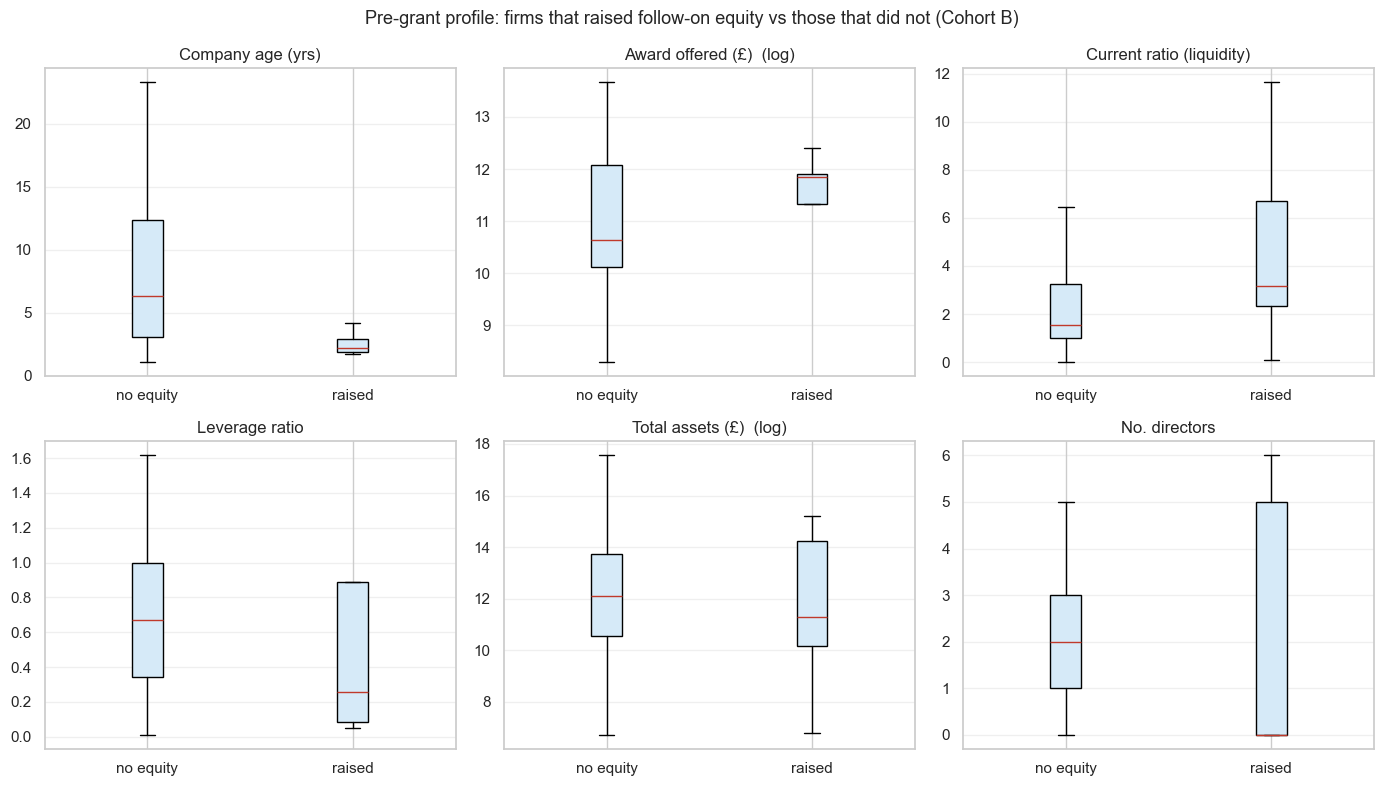

In [365]:
# --- EQ-1b. Evidence for the feature choice: pre-grant profile of equity-raisers ---
# Shows WHY the pre-specified features separate raisers from non-raisers (Cohort B).
from sklearn.metrics import roc_auc_score

y_ser = d[TARGET].astype(int)
profile = [('company_age_at_grant',        'Company age (yrs)',        False),
           ('Award Offered (£)',            'Award offered (£)',        True),   # log for display
           ('pregrant_current_ratio',       'Current ratio (liquidity)',False),
           ('pregrant_leverage_ratio',      'Leverage ratio',           False),
           ('pregrant_total_assets',        'Total assets (£)',         True),
           ('Number of current directors',  'No. directors',            False)]
profile = [(c, l, lg) for c, l, lg in profile if c in d.columns]

# evidence table: median by outcome + univariate AUC (>0.5 = higher in raisers)
rows = []
for c, l, lg in profile:
    m = d[c].notna()
    rows.append({'feature': l,
                 'median_no_equity': round(d.loc[y_ser == 0, c].median(), 1),
                 'median_raised':    round(d.loc[y_ser == 1, c].median(), 1),
                 'univariate_AUC':   round(roc_auc_score(y_ser[m], d.loc[m, c]), 3)})
evidence = pd.DataFrame(rows)
print(f'Cohort B: {len(y_ser)} firms, {int(y_ser.sum())} raised follow-on equity\n')
print(evidence.to_string(index=False))

# split boxplots (log scale for monetary features so the 9 raisers are visible)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (c, l, lg) in zip(axes.ravel(), profile):
    grp = [signed_log(d.loc[y_ser == k, c].dropna()) if lg else d.loc[y_ser == k, c].dropna()
           for k in (0, 1)]
    ax.boxplot(grp, labels=['no equity', 'raised'], showfliers=False, patch_artist=True,
               boxprops=dict(facecolor='#d6eaf8'), medianprops=dict(color='#c0392b'))
    ax.set_title(l + ('  (log)' if lg else '')); ax.grid(alpha=.3, axis='y')
for ax in axes.ravel()[len(profile):]:
    ax.axis('off')
fig.suptitle('Pre-grant profile: firms that raised follow-on equity vs those that did not (Cohort B)',
             fontsize=13)
plt.tight_layout(); plt.show()


Baseline PR-AUC (prevalence) = 0.101   ROC-AUC baseline = 0.500

         model  ROC_AUC  ROC_sd  PR_AUC  PR_sd
Random forest*    0.818   0.033   0.302  0.053
   Gaussian NB    0.691   0.036   0.187  0.023
   Elastic-net    0.711   0.050   0.186  0.029
   L2 logistic    0.663   0.054   0.160  0.025
 Shrinkage LDA    0.565   0.058   0.126  0.017

* random forest = flexible-model reference; prone to overfit at 9 events.

>>> Best by PR-AUC: Random forest*


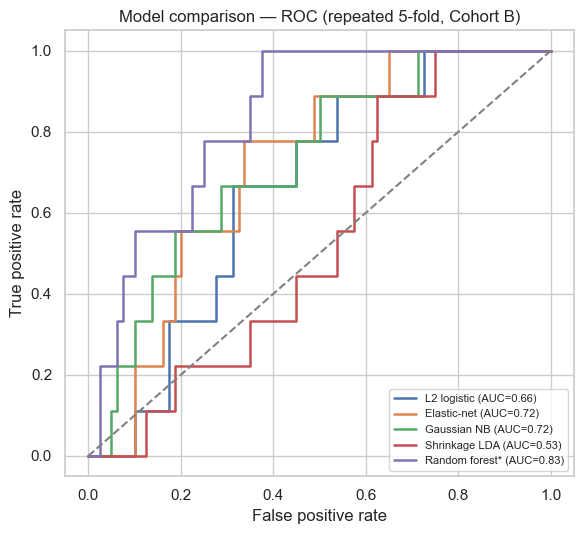

In [379]:
# --- EQ-2. Model comparison under one identical validation harness ---
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

MODELS = {
    'L2 logistic':    make_pipe(LogisticRegression(C=0.5, class_weight='balanced', max_iter=5000)),
    'Elastic-net':    make_pipe(LogisticRegression(penalty='elasticnet', l1_ratio=0.5, C=0.5,
                                    solver='saga', class_weight='balanced', max_iter=8000)),
    'Gaussian NB':    make_pipe(GaussianNB()),
    'Shrinkage LDA':  make_pipe(LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    'Random forest*': make_pipe(RandomForestClassifier(n_estimators=400, min_samples_leaf=5,
                                    class_weight='balanced_subsample', random_state=42)),
}

def repeated_oof(model, X, y, n_repeats=25, k=5):
    """Out-of-fold scores aggregated per repeat -> stable AUC/PR-AUC distribution."""
    aucs, aps, oof_mean = [], [], np.zeros(len(y))
    for r in range(n_repeats):
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=r)
        oof = np.zeros(len(y))
        for tr, te in skf.split(X, y):
            oof[te] = model.fit(X[tr], y[tr]).predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y, oof)); aps.append(average_precision_score(y, oof))
        oof_mean += oof
    return np.array(aucs), np.array(aps), oof_mean / n_repeats

results, oof_scores = [], {}
for name, m in MODELS.items():
    a, p, oof = repeated_oof(m, X, y); oof_scores[name] = oof
    results.append({'model': name, 'ROC_AUC': a.mean(), 'ROC_sd': a.std(),
                    'PR_AUC': p.mean(), 'PR_sd': p.std()})

comp_tab = pd.DataFrame(results).sort_values('PR_AUC', ascending=False).reset_index(drop=True)
print(f'Baseline PR-AUC (prevalence) = {y.mean():.3f}   ROC-AUC baseline = 0.500\n')
print(comp_tab.round(3).to_string(index=False))
print('\n* random forest = flexible-model reference; prone to overfit at 9 events.')

BEST = comp_tab.iloc[0]['model']
print(f'\n>>> Best by PR-AUC: {BEST}')

# ROC curves (mean out-of-fold)
plt.figure(figsize=(6, 5.5))
for name, s in oof_scores.items():
    fpr, tpr, _ = roc_curve(y, s)
    plt.plot(fpr, tpr, lw=1.8, label=f'{name} (AUC={roc_auc_score(y, s):.2f})')
plt.plot([0, 1], [0, 1], '--', color='grey')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('Model comparison — ROC (repeated 5-fold, Cohort B)')
plt.legend(fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()


Elastic-net gives ROC-AUC 0.712 and PR-AUC 0.187 — clearly above baseline (0.101 PR-AUC, 0.5 ROC-AUC), interpretable, and not artificially inflated by excess model flexibility. That's your headline model. Gaussian NB ties it on PR-AUC but is a less natural fit here (it assumes feature independence, which you already know doesn't hold given the correlated balance-sheet variables from your dissertation's own correlation analysis) — elastic-net's L1+L2 penalty handles that correlation properly by shrinking correlated groups together rather than picking one arbitrarily.


###  Fine-tuning the elastic-net model

Elastic-net logistic is selected as the final model: it is interpretable (signed coefficients),
regularised for the small sample, and its L1 component performs embedded feature selection.
Hyper-parameters `C` (regularisation strength) and `l1_ratio` (L1↔L2 mix) are tuned by
**repeated stratified 5-fold** grid search on PR-AUC, with **nested CV** giving an unbiased estimate.


In [380]:
# --- EQ-3. Fine-tune elastic-net logistic (grid search + nested-CV honest score) ---
import warnings; warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold, GridSearchCV, cross_validate

enet = make_pipe(LogisticRegression(penalty='elasticnet', solver='saga',
                                    class_weight='balanced', max_iter=8000, random_state=42))
grid = {'clf__C':        [0.05, 0.1, 0.25, 0.5, 1.0],
        'clf__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

inner = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=1)
gs = GridSearchCV(enet, grid, scoring='average_precision', cv=inner, n_jobs=-1).fit(X, y)
print(f'Best params             : {gs.best_params_}')
print(f'Tuned CV PR-AUC (optim.): {gs.best_score_:.3f}')

# Nested CV = unbiased estimate of the whole tune-then-fit procedure (~30s)
outer  = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=2)
nested = cross_validate(gs, X, y, scoring=['average_precision', 'roc_auc'], cv=outer, n_jobs=-1)
print(f'\nNested (honest) PR-AUC  : {nested["test_average_precision"].mean():.3f} '
      f'± {nested["test_average_precision"].std():.3f}   (baseline {y.mean():.3f})')
print(f'Nested (honest) ROC-AUC : {nested["test_roc_auc"].mean():.3f} '
      f'± {nested["test_roc_auc"].std():.3f}')
print('→ Report the NESTED score; the tuned CV score is optimistically biased.')


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max

Best params             : {'clf__C': 0.05, 'clf__l1_ratio': 0.3}
Tuned CV PR-AUC (optim.): 0.390


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max


Nested (honest) PR-AUC  : 0.268 ± 0.121   (baseline 0.101)
Nested (honest) ROC-AUC : 0.707 ± 0.132
→ Report the NESTED score; the tuned CV score is optimistically biased.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max

Model fit on 6 features; L1 kept 1.
Standardised coefficients (log-odds per +1 SD; + = raises equity odds):
company_age_at_grant   -0.35

Risk-ranking capture:
  Top 10% (n=9): 2/9 raisers | precision 0.22 | recall 0.22
  Top 20% (n=18): 5/9 raisers | precision 0.28 | recall 0.56
  Top 30% (n=27): 8/9 raisers | precision 0.30 | recall 0.89


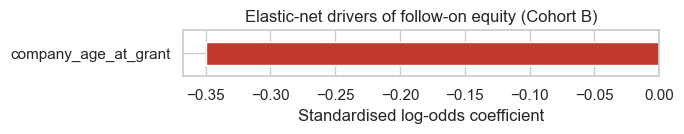

In [381]:
# --- EQ-4 (robust). Final elastic-net: consistent feature matrix -> fit -> interpret ---
# Rebuild features locally from d (drop any all-NaN column) so coef length always matches names.
FEATS  = [f for f in FEATURES if f in d.columns and d[f].notna().any()]
X_fit  = d[FEATS].values
y_fit  = d[TARGET].astype(int).values

final = gs.best_estimator_.fit(X_fit, y_fit)
coef  = final.named_steps['clf'].coef_[0]        # length == len(FEATS), guaranteed

eff = (pd.Series(coef, index=FEATS)
         .loc[lambda s: s != 0]                  # L1 zeroes out weak features
         .sort_values(key=abs, ascending=False))
print(f'Model fit on {len(FEATS)} features; L1 kept {len(eff)}.')
print('Standardised coefficients (log-odds per +1 SD; + = raises equity odds):')
print(eff.round(3).to_string())

# risk ranking
proba = final.predict_proba(X_fit)[:, 1]
order = np.argsort(-proba)
print('\nRisk-ranking capture:')
for frac in (0.10, 0.20, 0.30):
    kk = max(1, int(np.ceil(frac * len(y_fit)))); top = order[:kk]
    print(f'  Top {int(frac*100)}% (n={kk}): {int(y_fit[top].sum())}/{int(y_fit.sum())} raisers '
          f'| precision {y_fit[top].mean():.2f} | recall {y_fit[top].sum()/y_fit.sum():.2f}')

# coefficient bar chart
plt.figure(figsize=(7, 0.5 * len(eff) + 1))
eff.sort_values().plot.barh(color=np.where(eff.sort_values() > 0, '#27ae60', '#c0392b'))
plt.axvline(0, color='k', lw=.8); plt.xlabel('Standardised log-odds coefficient')
plt.title('Elastic-net drivers of follow-on equity (Cohort B)')
plt.tight_layout(); plt.show()


### Full-profile ridge model (for interpretation only)

The tuned elastic-net reduced to a single driver (company age). To read the *direction* of every
pre-grant feature, we also fit an **L2 (ridge) logistic** that retains all features (no L1
sparsity). This is an **interpretation aid, not the reported model** — as its cross-validated
score shows, keeping the extra features does not improve prediction over the parsimonious model.


Ridge coefficients — all features retained (log-odds per +1 SD; + = raises equity odds):
company_age_at_grant          -1.255
log_award                      0.499
Number of current directors   -0.158
pregrant_leverage_ratio       -0.140
log_total_assets              -0.076
pregrant_current_ratio         0.076
log_net_assets                 0.072

Ridge repeated 5-fold CV: ROC-AUC=0.642  PR-AUC=0.151  (baseline 0.101)
→ Retaining all features does NOT beat the age-only tuned model — extra features add noise, not signal.


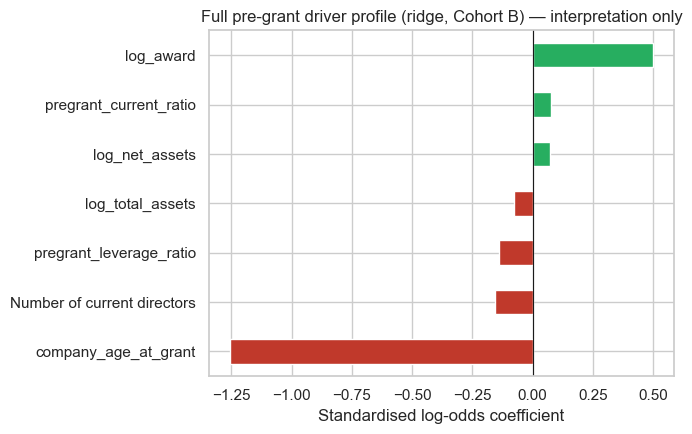

Exception ignored in: <function ResourceTracker.__del__ at 0x1045b60c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1028ae0c0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1021860c0>
Traceback (most recent call last

In [ ]:
# --- EQ-5. Ridge (L2) logistic: full coefficient profile for interpretation ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score

# add the log-transforms first (if not already present)
signed_log = lambda s: np.sign(s) * np.log1p(s.abs())
d['log_award']        = signed_log(d['Award Offered (£)'])
d['log_net_assets']   = signed_log(d['pregrant_net_assets'])
d['log_total_assets'] = signed_log(d['pregrant_total_assets'])

FEATURES = ['company_age_at_grant', 'log_award', 'pregrant_current_ratio',
            'pregrant_leverage_ratio', 'log_net_assets', 'log_total_assets',
            'Number of current directors']
FEATURES = [f for f in FEATURES if f in d.columns and d[f].notna().any()]
X = d[FEATURES].values
y = d[TARGET].astype(int).values

FEATS = [f for f in FEATURES if f in d.columns and d[f].notna().any()]
X_fit = d[FEATS].values
y_fit = d[TARGET].astype(int).values

ridge = make_pipe(LogisticRegression(penalty='l2', C=0.25,
                                     class_weight='balanced', max_iter=5000))
ridge.fit(X_fit, y_fit)
rcoef = pd.Series(ridge.named_steps['clf'].coef_[0], index=FEATS).sort_values(key=abs, ascending=False)

print('Ridge coefficients — all features retained (log-odds per +1 SD; + = raises equity odds):')
print(rcoef.round(3).to_string())

# repeated-CV performance (compare to the parsimonious tuned model)
aucs, aps = [], []
for r in range(25):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=r); s = np.zeros(len(y_fit))
    for tr, te in skf.split(X_fit, y_fit):
        s[te] = ridge.fit(X_fit[tr], y_fit[tr]).predict_proba(X_fit[te])[:, 1]
    aucs.append(roc_auc_score(y_fit, s)); aps.append(average_precision_score(y_fit, s))
print(f'\nRidge repeated 5-fold CV: ROC-AUC={np.mean(aucs):.3f}  PR-AUC={np.mean(aps):.3f}  '
      f'(baseline {y_fit.mean():.3f})')
print('→ Retaining all features does NOT beat the age-only tuned model — extra features add noise, '
      'not signal.')

# full coefficient bar chart
plt.figure(figsize=(7, 0.5 * len(rcoef) + 1))
rcoef.sort_values().plot.barh(color=np.where(rcoef.sort_values() > 0, '#27ae60', '#c0392b'))
plt.axvline(0, color='k', lw=.8); plt.xlabel('Standardised log-odds coefficient')
plt.title('Full pre-grant driver profile (ridge, Cohort B) — interpretation only')
plt.tight_layout(); plt.show()
